In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path
import seaborn as sns
import numpy as np
import itertools as it
import pandas as pd
import yaml
from analysis_tools import load_ibd, bin_purple, stack_purple, yaml_arg, get_ne
from simulations import DemographicSetup
from kinship import DEGREES

def setup_plotting_style():
    """
    Set up consistent plotting style for all figures
    """
    # Add custom font directory
    font_dir = str(Path.home() / '.fonts')
    font_files = fm.findSystemFonts(fontpaths=[font_dir])
    print(font_files)
    for font_file in font_files:
        fm.fontManager.addfont(font_file)
    
    # Set Helvetica as the font family
    plt.rcParams['font.family'] = 'Nimbus Sans L'

    
    # Set font sizes
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.labelsize'] = 12
    
    
    # Set default figure size
    plt.rcParams['figure.figsize'] = [10, 6]
    
    # Set other styling preferences
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.linestyle'] = '--'
    plt.rcParams['grid.alpha'] = 0.7
    
setup_plotting_style()

plt.rcParams.update({
    "figure.figsize": (6, 4),      # Larger figure size
    "font.size": 11,               # Larger font size
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 11,
    "figure.dpi": 300,
})


path = "/gpfs/data/sramacha/cwilli50/Thesis_Chapter3/figures"

# paths = ["2025-02-25_22-43-30.229837736", "2025-02-25_23-13-55.999897838", "2025-03-02_20-48-48.689648497", "2025-03-02_21-10-19.719367077"]
# labels = [r"$N_e$=10,000" ,r"$N_e$=100,000", "Quebec", "OOA2-European"]
paths = ["2025-02-25_22-43-30.229837736", "2025-07-03_14-32-07.268359698", "2025-03-02_20-48-48.689648497", "2025-03-02_21-10-19.719367077"]
labels = [r"$N_e$=10,000" ,r"$N_e$=10,000\nmono", "Quebec", "OOA2-European"]
colors = [
    '#264653',  # Dark teal
    '#f4a261',  # Peach
    '#006d77',  # Deep aqua
    '#45b69c',  # Mint
]

# colors = ["#26547C", "#FFD166", "#B279A7", "#3F784C"]
label_color = {l: c for l, c in zip(labels, colors)}
path_labels = list(zip(paths, labels))

['/users/cwilli50/.fonts/NimbusSanL-Reg.otf', '/users/cwilli50/.fonts/NimbusSanL-BolIta.otf', '/users/cwilli50/.fonts/NimbusSanL-Bol.otf', '/users/cwilli50/.fonts/NimbusSanL-RegIta.otf']


##### Ne trajectories

Getting custom demographic model


/users/cwilli50/.conda/envs/chap3/lib/python3.13/site-packages/stdpopsim/catalog/HomSap/demographic_models.py:158: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  time=int(extended_GF.time.head(1) - 1), rate=0
/users/cwilli50/.conda/envs/chap3/lib/python3.13/site-packages/stdpopsim/catalog/HomSap/demographic_models.py:161: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  time=int(extended_GF.time.tail(1) + 1), rate=0


Getting custom demographic model
Getting custom demographic model
Getting custom demographic model


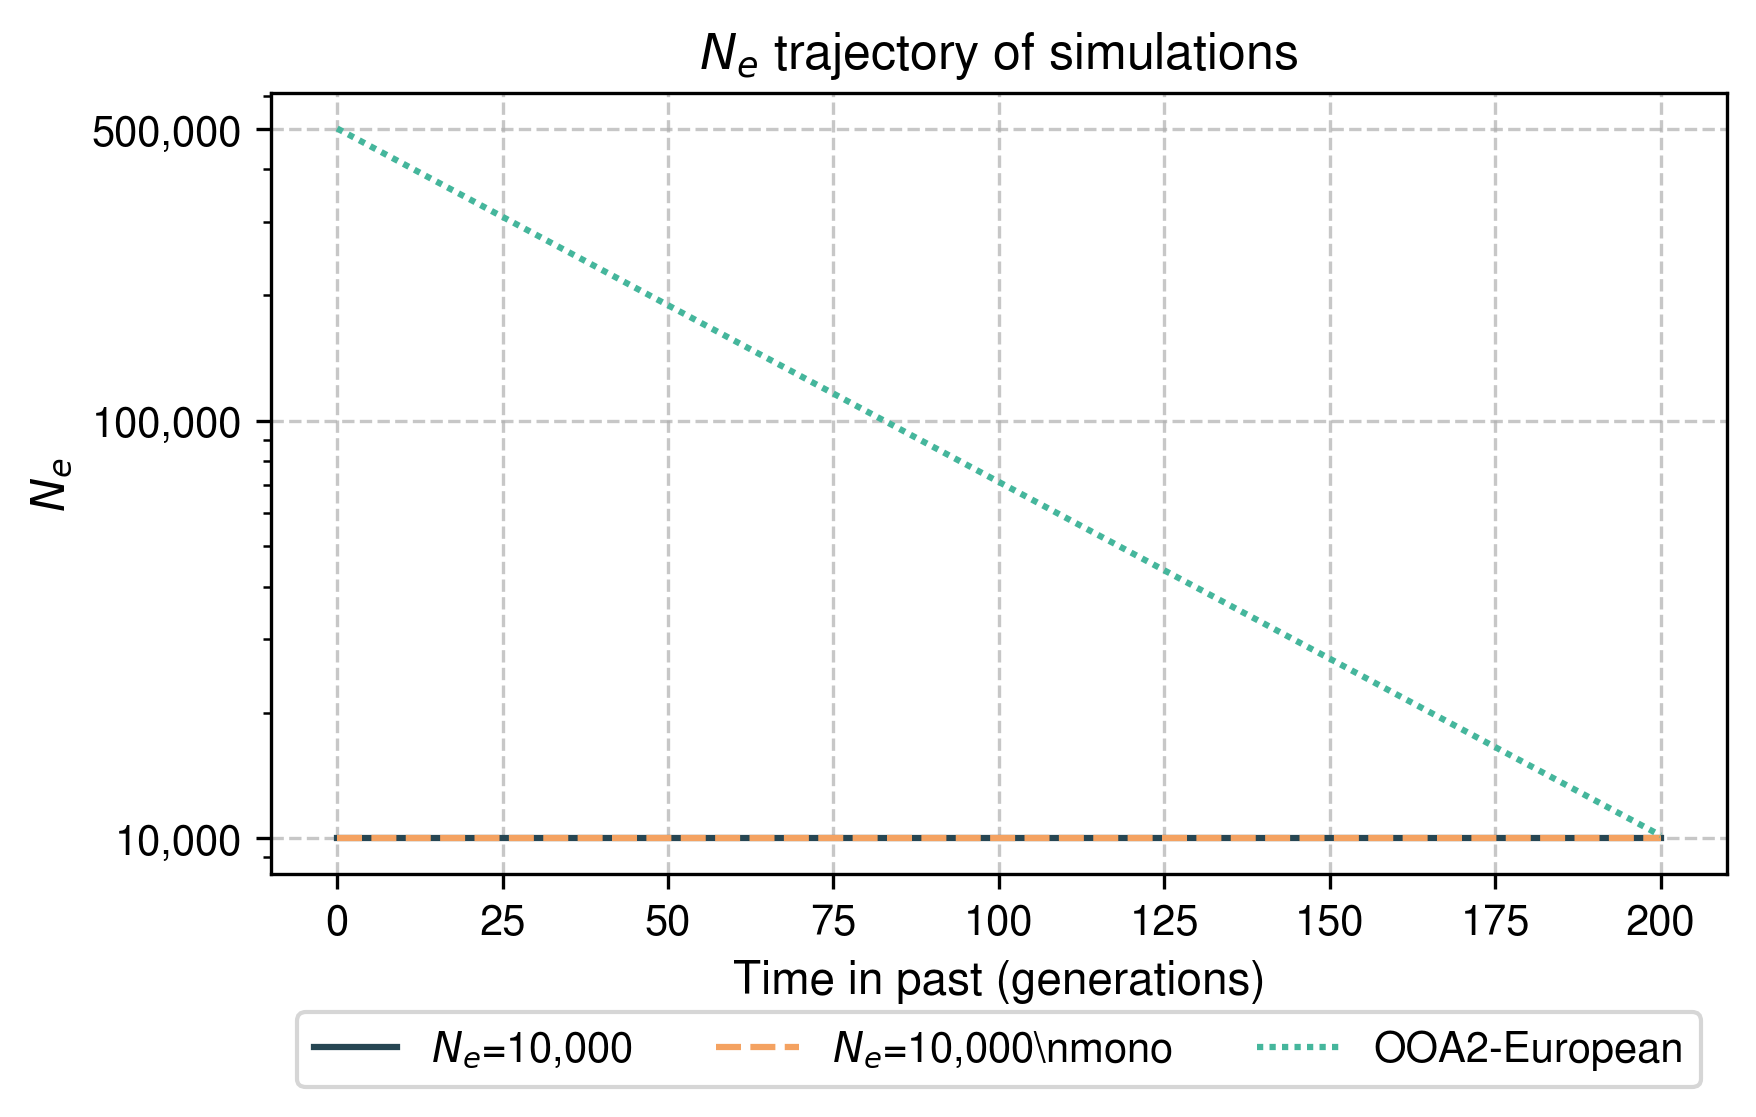

In [2]:
tmp = []
for p, label in path_labels:
    try:
        demo = DemographicSetup.create(yaml.safe_load(open(f"{p}/args.yaml")))
    except:
        continue
    df = get_ne(demo, max_g=200)
    df["Simulation"] = label
    tmp.append(df)

ne_df = pd.concat(tmp)

sns.lineplot(data=ne_df, x="GEN", y="NE", hue="Simulation", palette=label_color, style="Simulation")

plt.ylabel(f"$N_e$")
plt.xlabel("Time in past (generations)")
plt.yscale("log")
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.3), ncol=3)
plt.title(r"$N_e$ trajectory of simulations")

ax = plt.gca()  # Get current axes
ax.set_yticks([10000, 100000, 500000])  # or [1e4, 1e5, 5e5]

# If you want to format the labels in a specific way:
ax.set_yticklabels(['10,000', '100,000', '500,000'])

plt.tight_layout()

plt.savefig(f"{path}/simulation_ne.png", dpi=500)

##### Plot showing the probability of two ancestor sets overlapping as a function of g and N

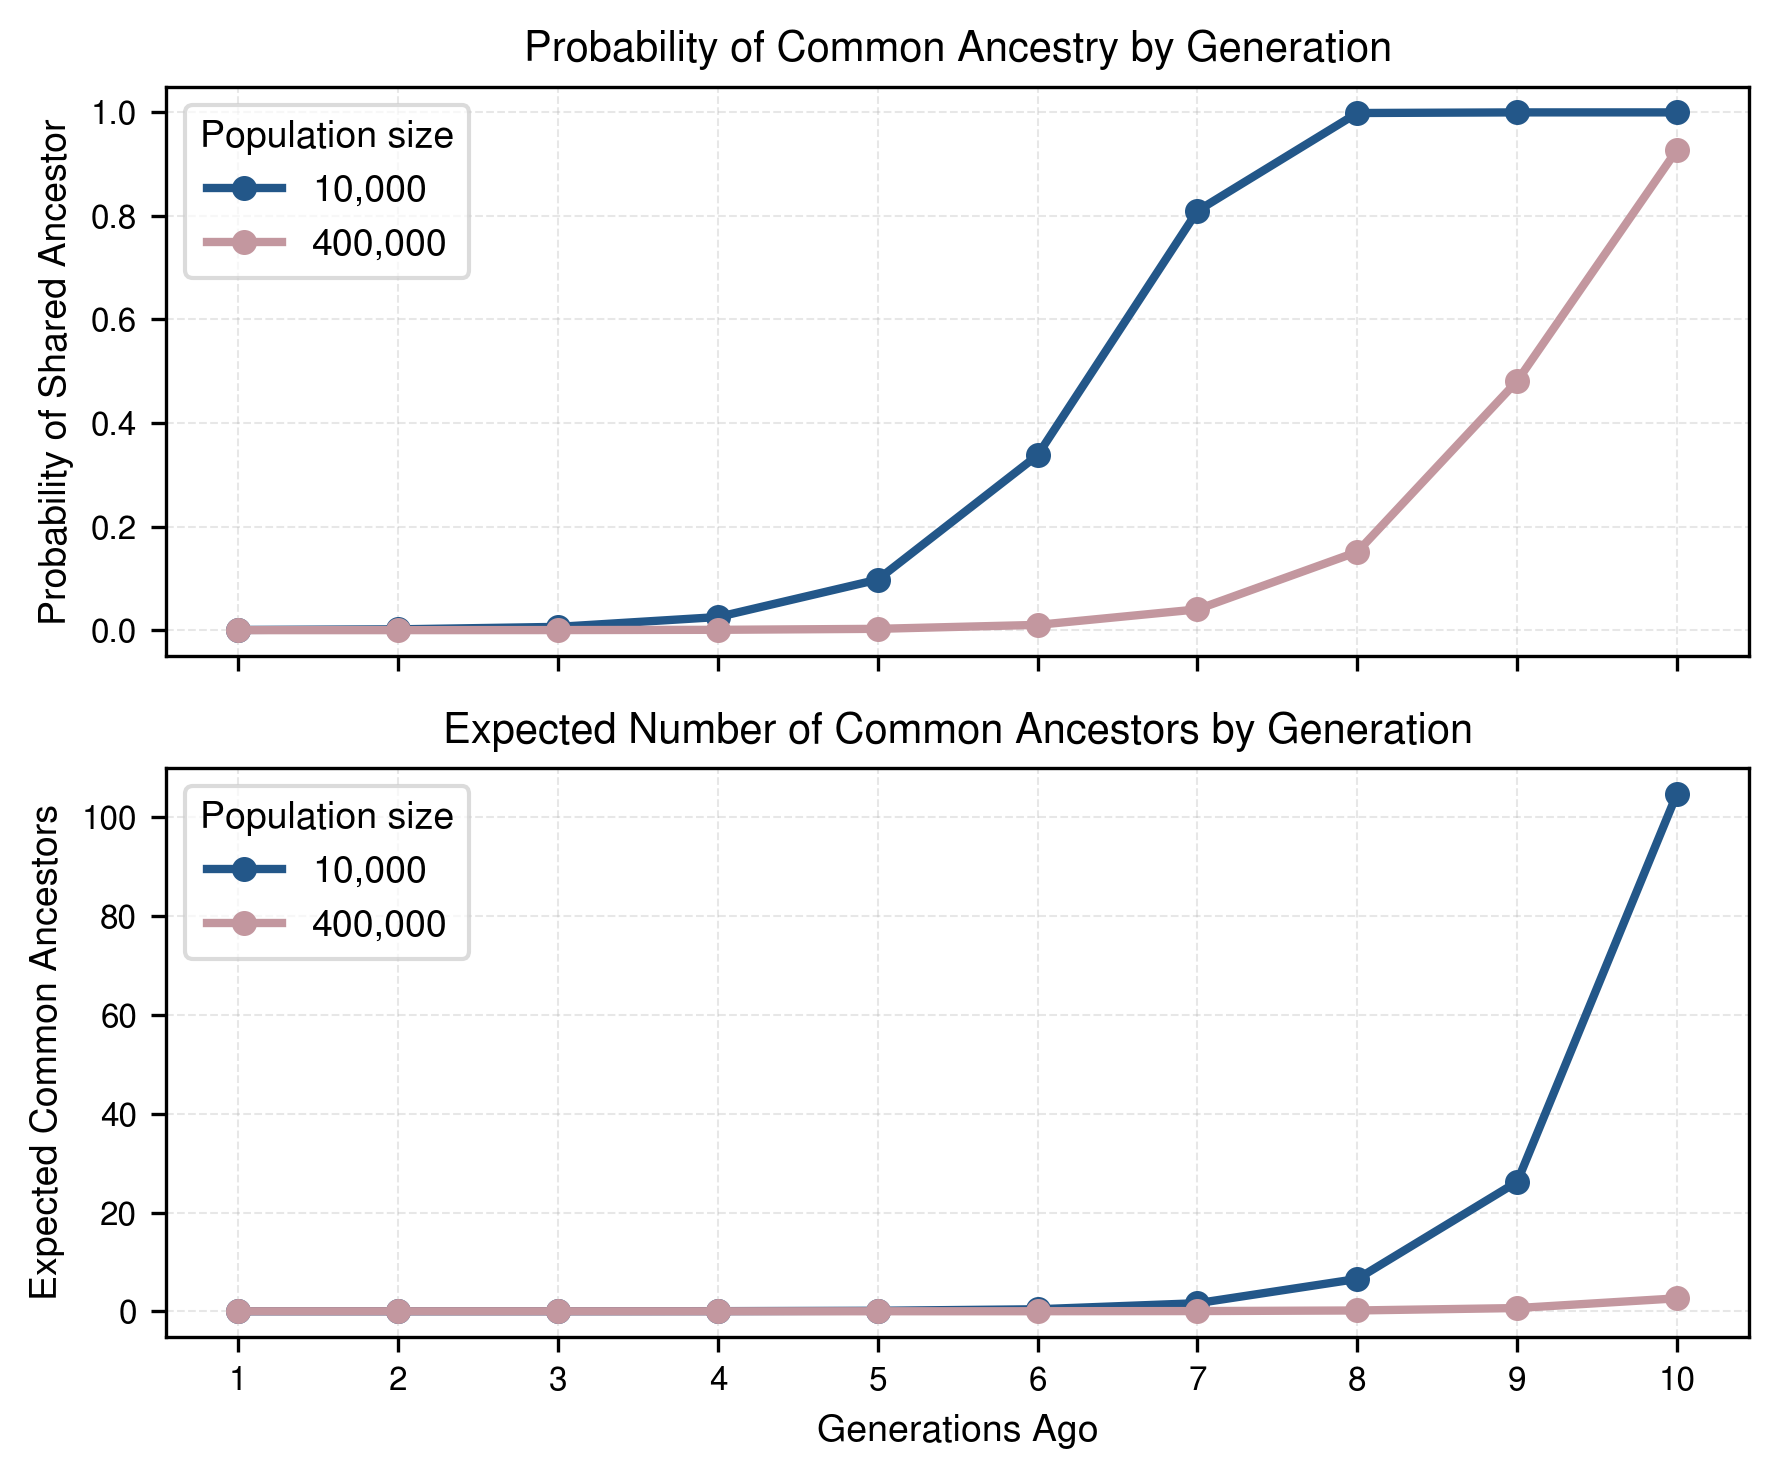

In [3]:
from scipy.stats import hypergeom

g_range = np.arange(10) + 1

N_sizes = [10000, 400000]

k = 0
rows = []
exp_rows = []
for g, N in it.product(g_range, N_sizes):
    K = 2**g  # Number of descendants
    n = 2**g  # Sample size
    rv = hypergeom(N, K, n)  # Note: hypergeom takes (M, n, N) where M is population size, n is success states, N is sample size
    prob = 1-rv.pmf(k)
    rows.append([g, "10,000" if N==10000 else "400,000", prob])
    exp_rows.append([g, "10,000" if N==10000 else "400,000", n*(K/N)])

plot_df = pd.DataFrame(rows, columns=["Generations ago", "Population size", "Probability"])
exp_df = pd.DataFrame(exp_rows, columns=["Generations ago", "Population size", "Expected common ancestors"])

plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 9,
    "legend.title_fontsize": 9,
    "figure.dpi": 300,
})


# Define your specific colors
colors = {"10,000": "#235789", "400,000": "#C3979F"}

# Create a figure with two subplots (stacked vertically)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

# Plot 1: Probability of shared ancestor
for name, group in plot_df.groupby("Population size"):
    ax1.plot(group["Generations ago"], group["Probability"], 
            marker='o', markersize=5, linewidth=2, 
            label=name, color=colors[name])

ax1.set_ylabel("Probability of Shared Ancestor")
ax1.set_title("Probability of Common Ancestry by Generation")
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax1.legend(title="Population size", framealpha=0.7)

# Plot 2: Expected number of common ancestors
for name, group in exp_df.groupby("Population size"):
    ax2.plot(group["Generations ago"], group["Expected common ancestors"], 
            marker='o', markersize=5, linewidth=2, 
            label=name, color=colors[name])

ax2.set_xlabel("Generations Ago")
ax2.set_ylabel("Expected Common Ancestors")
ax2.set_title("Expected Number of Common Ancestors by Generation")
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax2.legend(title="Population size", framealpha=0.7)

# Set x-axis ticks to include all generation values
ax2.set_xticks(g_range)
ax2.set_xticklabels(g_range)

# Adjust layout
plt.tight_layout()

# Save with settings optimized for LaTeX inclusion
plt.savefig(f'{path}/ancestry_probability.png', bbox_inches='tight', dpi=300)


##### Age of IBD segments by segment length

####

In [5]:
dfs = []
for p, lab in path_labels:
    tmp = pd.read_csv(f"{p}/tmrca_by_length.csv")
    tmp = pd.melt(tmp, id_vars="length")
    tmp["label"] = lab
    dfs.append(tmp)

len_distr = pd.concat(dfs)
len_distr

FileNotFoundError: [Errno 2] No such file or directory: '2025-07-03_14-32-07.268359698/tmrca_by_length.csv'

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import MaxNLocator

def plot_multiple_percentiles(df, percentiles=[5, 50, 95], figsize=(8, 6), 
                            save_path=None, dpi=300, publication_ready=True):
    """
    Plot multiple percentiles in a vertical arrangement of subplots.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing columns 'length', 'variable', 'value', and 'label'
    percentiles : list
        List of percentiles to plot (e.g., [5, 50, 95])
    figsize : tuple
        Figure size as (width, height) in inches
    save_path : str, optional
        Path to save the figure. If None, figure is not saved.
    dpi : int
        Resolution for saved figure
    publication_ready : bool
        If True, uses settings appropriate for publication
        
    Returns:
    --------
    fig, axes : matplotlib figure and list of axes objects
    """
    # Create a copy to avoid modifying the original
    data = df.copy()
    
    # Convert percentile strings to numeric values
    data['percentile'] = data['variable'].str.rstrip('%').astype(float)
    
    # Define the specific lengths to include with reduced crowding:
    # 2, 4, 6, 8, 10, 15, 20, ..., 45, 50, 60, ..., 100
    allowed_lengths = list(range(2, 11, 2)) + list(range(10, 51, 5)) + list(range(50, 101, 10))
    allowed_lengths = sorted(set(allowed_lengths))

    exp_tmrca = [50 / l for l in allowed_lengths]
    
    # Filter data to only include the specified lengths
    data = data[data['length'].isin(allowed_lengths)]
    
    # Set publication styling
    if publication_ready:
        plt.rcParams.update({
            'font.family': 'sans-serif',
            'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
            'font.size': 10,
            'axes.labelsize': 11,
            'axes.titlesize': 12,
            'xtick.labelsize': 9,
            'ytick.labelsize': 9,
            'legend.fontsize': 9,
            'figure.titlesize': 13
        })
    
    # Create figure with subplots - CRITICAL: Do NOT use sharex=True
    fig = plt.figure(figsize=figsize)
    axes = []
    
    # Create each subplot manually to ensure ticks on x-axis
    for i in range(len(percentiles)):
        if i == 0:  # First subplot
            ax = fig.add_subplot(len(percentiles), 1, i+1)
        else:  # Subsequent subplots
            ax = fig.add_subplot(len(percentiles), 1, i+1, sharex=axes[0])
        axes.append(ax)
    
    # Get unique labels for coloring
    labels = data['label'].unique()
    
    # Create color palette
    colors = sns.color_palette("viridis", len(labels))
    color_dict = dict(zip(labels, colors))
    
    # Process each subplot
    for i, percentile in enumerate(percentiles):
        ax = axes[i]
        
        # Format the percentile string to match data
        percentile_str = f"{float(percentile):.1f}%"
        
        # Filter for this percentile
        percentile_data = data[data['variable'] == percentile_str]
        
        if percentile_data.empty:
            ax.text(0.5, 0.5, f"No data for {percentile}th percentile", 
                   ha='center', va='center', transform=ax.transAxes)
            continue

        ax.plot(allowed_lengths, exp_tmrca, linestyle="--", color="lightgrey")
        
        # Plot each label as a separate line
        for label in labels:
            label_data = percentile_data[percentile_data['label'] == label].sort_values('length')
            
            if not label_data.empty:
                # For legend, use first part of label (before \n)
                legend_label = label.split('\\n')[0] if '\\n' in label else label
                
                ax.plot(label_data['length'], label_data['value'], 'o-', 
                        label=legend_label, linewidth=1.5, markersize=4, 
                        markeredgecolor='white', alpha=0.7)
        
        # Set title on the top plot
        if i == 0:
            ax.set_title(f'Distribution of IBD segment ages')
            # Add legend to first subplot
            ax.legend(loc='upper right', title="Population history", fontsize=8, title_fontsize=9)

        
        ax.set_ylabel('Age (generations)')
        
        # Add percentile label on the right side
        ax.text(1.02, 0.5, f'{percentile}th percentile', transform=ax.transAxes,
                va='center', ha='left', fontsize=10)
        
        # Add grid with minor lines for more horizontal divisions
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.grid(True, which='minor', axis='y', linestyle=':', alpha=0.2)
        
        # CRITICAL: Force the ticks on x-axis
        ax.xaxis.set_tick_params(which='both', bottom=True)
        
        # Bottom subplot gets x-axis label
        ax.set_xticklabels(allowed_lengths, ha='center', fontsize=7)
    
        # Set y-axis ticks to be integer when possible
        ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
        ax.yaxis.set_minor_locator(MaxNLocator(nbins=10))
    
    # Ensure all subplots share the same x-axis ticks
    for ax in axes:
        ax.set_xticks(allowed_lengths)

    axes[-1].set_xlabel('IBD segment length (centiMorgan)')
    
    # Adjust spacing
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.15, right=0.85)
    
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print("Saved to " + save_path)
    
    return fig, axes

# Example usage:
plot_multiple_percentiles(len_distr, percentiles=[5, 50, 95], save_path=f"{path}/tmrca_by_length.png", dpi=500)

NameError: name 'len_distr' is not defined

In [7]:
degrees = sorted(DEGREES.keys())
sorted_degrees = sorted(degrees, key=lambda x: int("".join([i for i in x if i.isnumeric()])))
print(degrees)

mat = np.load("2025-02-25_22-43-30.229837736/tmrca_by_kinship.npy")
mat.shape

['10th', '11th', '1st', '2nd', '3rd', '4th', '5th', '6th', '7th', '8th', '9th']


(11, 300, 12)

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def plot_tmrca_grid(paths, l_list, degrees, percentiles=[5, 50, 95], 
                    figsize=None, use_log_scale=True, skip_degrees=None, 
                    custom_order=None, x_label='Degree', y_label='Age',
                    path_labels=None, l_labels=None):
    """
    Creates a grid of plots for multiple cM values and data paths.
    
    Parameters:
    -----------
    paths : list
        List of paths to directories containing tmrca_by_kinship.npy files
    l_list : list
        List of centiMorgan (cM) indices to use from the matrices
    degrees : list
        List of degree labels corresponding to the indices in the matrices
    percentiles : list
        List of percentile indices to plot (default: [5, 50, 95])
    figsize : tuple or None
        Figure size as (width, height). If None, will be calculated based on grid size
    use_log_scale : bool
        Whether to use log scale for y-axis
    skip_degrees : list or None
        List of degree labels to skip (e.g., ["11th"])
    custom_order : list or None
        Optional list specifying the custom order for degrees on the x-axis
    x_label : str
        Label for x-axis
    y_label : str
        Label for y-axis
    path_labels : list or None
        Optional list of labels for each path (rows)
    l_labels : list or None
        Optional list of labels for each l value (columns)
        
    Returns:
    --------
    fig, axs : matplotlib figure and axes grid
    """
    # Calculate grid dimensions
    n_rows = len(paths)
    n_cols = len(l_list)
    
    # Calculate figsize if not provided
    if figsize is None:
        figsize = (n_cols * 5, n_rows * 4)

    plt.close()

    plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 20
})
        
    # Create figure and axes grid
    fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False, sharey=True)
    
    # Define percentile labels
    perc_values = percentiles
    perc_labels = [f"{p}%" for p in perc_values]
    
    # Map percentile values to indices in the matrix
    # Assuming indices 1, 6, 11 correspond to 5%, 50%, 95%
    percentile_index_map = {5: 1, 50: 6, 95: 11}  # Adjust this mapping as needed
    perc_indices = [percentile_index_map.get(p, p) for p in perc_values]
    
    # Skip specific degrees if requested
    skip_degrees = skip_degrees or []
    
    # Set categorical order for degrees
    if custom_order is None:
        # Use the original degrees list as the order, excluding skipped degrees
        sorted_degrees = [d for d in degrees if d not in skip_degrees]
    else:
        sorted_degrees = custom_order
    
    # Use path labels if provided, otherwise use directory names
    if path_labels is None:
        path_labels = [os.path.basename(path) for path in paths]
    
    # Use l labels if provided, otherwise use l values
    if l_labels is None:
        l_labels = [f"cM={l}" for l in l_list]
    
    # Create plots for each path and l combination
    for row_idx, path in enumerate(paths):
        for col_idx, l in enumerate(l_list):
            # Get current axis
            ax = axs[row_idx, col_idx]
            
            try:
                # Load the data
                mat = np.load(f"{path}/tmrca_by_kinship.npy")
                
                # Initialize rows for DataFrame
                rows = []
                
                # Create rows for DataFrame
                for index, d in enumerate(degrees):
                    if d in skip_degrees:
                        continue
                    
                    # Check if there are observations
                    if mat[index, l, 0] == 0:
                        continue
                        
                    for q_idx, lab in zip(perc_indices, perc_labels):
                        rows.append([d, lab, mat[index, l, q_idx]])
                
                # Create DataFrame
                df = pd.DataFrame(rows, columns=["Degree", "Percentile", "Age (generations)"])
                
                # Check if we have data
                if len(df) == 0:
                    ax.text(0.5, 0.5, "No data", ha='center', va='center')
                    ax.set_xticks([])
                    ax.set_yticks([])
                    continue
                
                # Filter sorted_degrees to only include degrees that have data
                available_degrees = df['Degree'].unique()
                plot_sorted_degrees = [d for d in sorted_degrees if d in available_degrees]

                exp_tmrca = {"1st": 1,
                             "2nd": 1,
                             "3rd": 3,
                             "4th": 4,
                             "5th": 5,
                             "6th": 6,
                             "7th": 7,
                             "8th": 8,
                             "9th": 9,
                             "10th": 10,
                             "11th": 11
                }

                exp_y = [exp_tmrca[i] for i in plot_sorted_degrees]
                
                # Set categorical order
                df['Degree'] = pd.Categorical(df['Degree'], categories=plot_sorted_degrees, ordered=True)
                
                # Filter data for each percentile
                df_5 = df[df['Percentile'] == '5%']
                df_50 = df[df['Percentile'] == '50%']
                df_95 = df[df['Percentile'] == '95%']
                
                # Create a line plot for the median (50%)
                sns.lineplot(data=df_50, x="Degree", y="Age (generations)", ax=ax, marker='o', 
                            color='navy', label='Median (50%)', linewidth=2)
                
                # Get x and y values for filling
                x_indices = range(len(plot_sorted_degrees))
                
                # Get y values for 5% and 95% percentiles, ensuring they match the sorted degrees
                y_lower = []
                y_upper = []
                
                for degree in plot_sorted_degrees:
                    lower_vals = df_5[df_5['Degree'] == degree]['Age (generations)'].values
                    upper_vals = df_95[df_95['Degree'] == degree]['Age (generations)'].values
                    
                    if len(lower_vals) > 0 and len(upper_vals) > 0:
                        y_lower.append(lower_vals[0])
                        y_upper.append(upper_vals[0])
                
                # Fill between 5% and 95%
                if len(y_lower) == len(x_indices) and len(y_upper) == len(x_indices):
                    ax.fill_between(x_indices, y_lower, y_upper, alpha=0.3, color='skyblue', label='5%-95% range')

                sns.lineplot(x=plot_sorted_degrees, y=exp_y, ax=ax, linestyle="--", color="grey")
                
                # Set log scale if requested
                if use_log_scale:
                    ax.set_yscale("log")
                
                # Set title for this subplot
                if row_idx == 0:
                    ax.set_title(l_labels[col_idx])

                if col_idx == n_cols - 1:
                    # Create a twin axis that shares the same y-scale
                    ax2 = ax.twinx()
                    # Make the second y-axis share the same limits as the first
                    ax2.set_ylim(ax.get_ylim())
                    # Hide the ticks on the second y-axis
                    ax2.tick_params(right=False, labelright=False)
                    # Set the secondary y-label
                    ax2.set_ylabel(path_labels[row_idx][1], color='black', rotation=0, fontsize=14, labelpad=60)

                    ax2.grid(False)

                
                # # Set y-label only for leftmost column
                # if col_idx == n_cols - 1:
                #     ax.yaxis.set_label_position("right")
                #     ax.set_ylabel(f"{path_labels[row_idx]}\n{y_label}")
                # else:
                #     ax.set_ylabel("")
                
                # Set x-label only for bottom row
                if row_idx == n_rows - 1:
                    ax.set_xlabel(x_label)
                else:
                    ax.set_xlabel("")
                    ax.set_xticklabels([])
                
                # Rotate x-tick labels if needed
                if len(plot_sorted_degrees) > 5:
                    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
                
                # Only show legend for the first plot
                # if row_idx == 0 and col_idx == 0:
                #     ax.legend(title="Percentile", loc='best')
                # else:
                ax.legend().set_visible(False)
                    
            except Exception as e:
                # Handle errors
                ax.text(0.5, 0.5, f"Error: {str(e)}", ha='center', va='center', wrap=True)
                ax.set_xticks([])
                ax.set_yticks([])

    handles, labels = axs[-1, -1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.99, 0.9), 
               title="Percentile", fontsize=12, title_fontsize=13)
    

    fig.suptitle("IBD segment age conditional on degree of relatedness", fontsize=18, y=0.97)

    plt.tight_layout(pad=3.0)
    return fig, axs

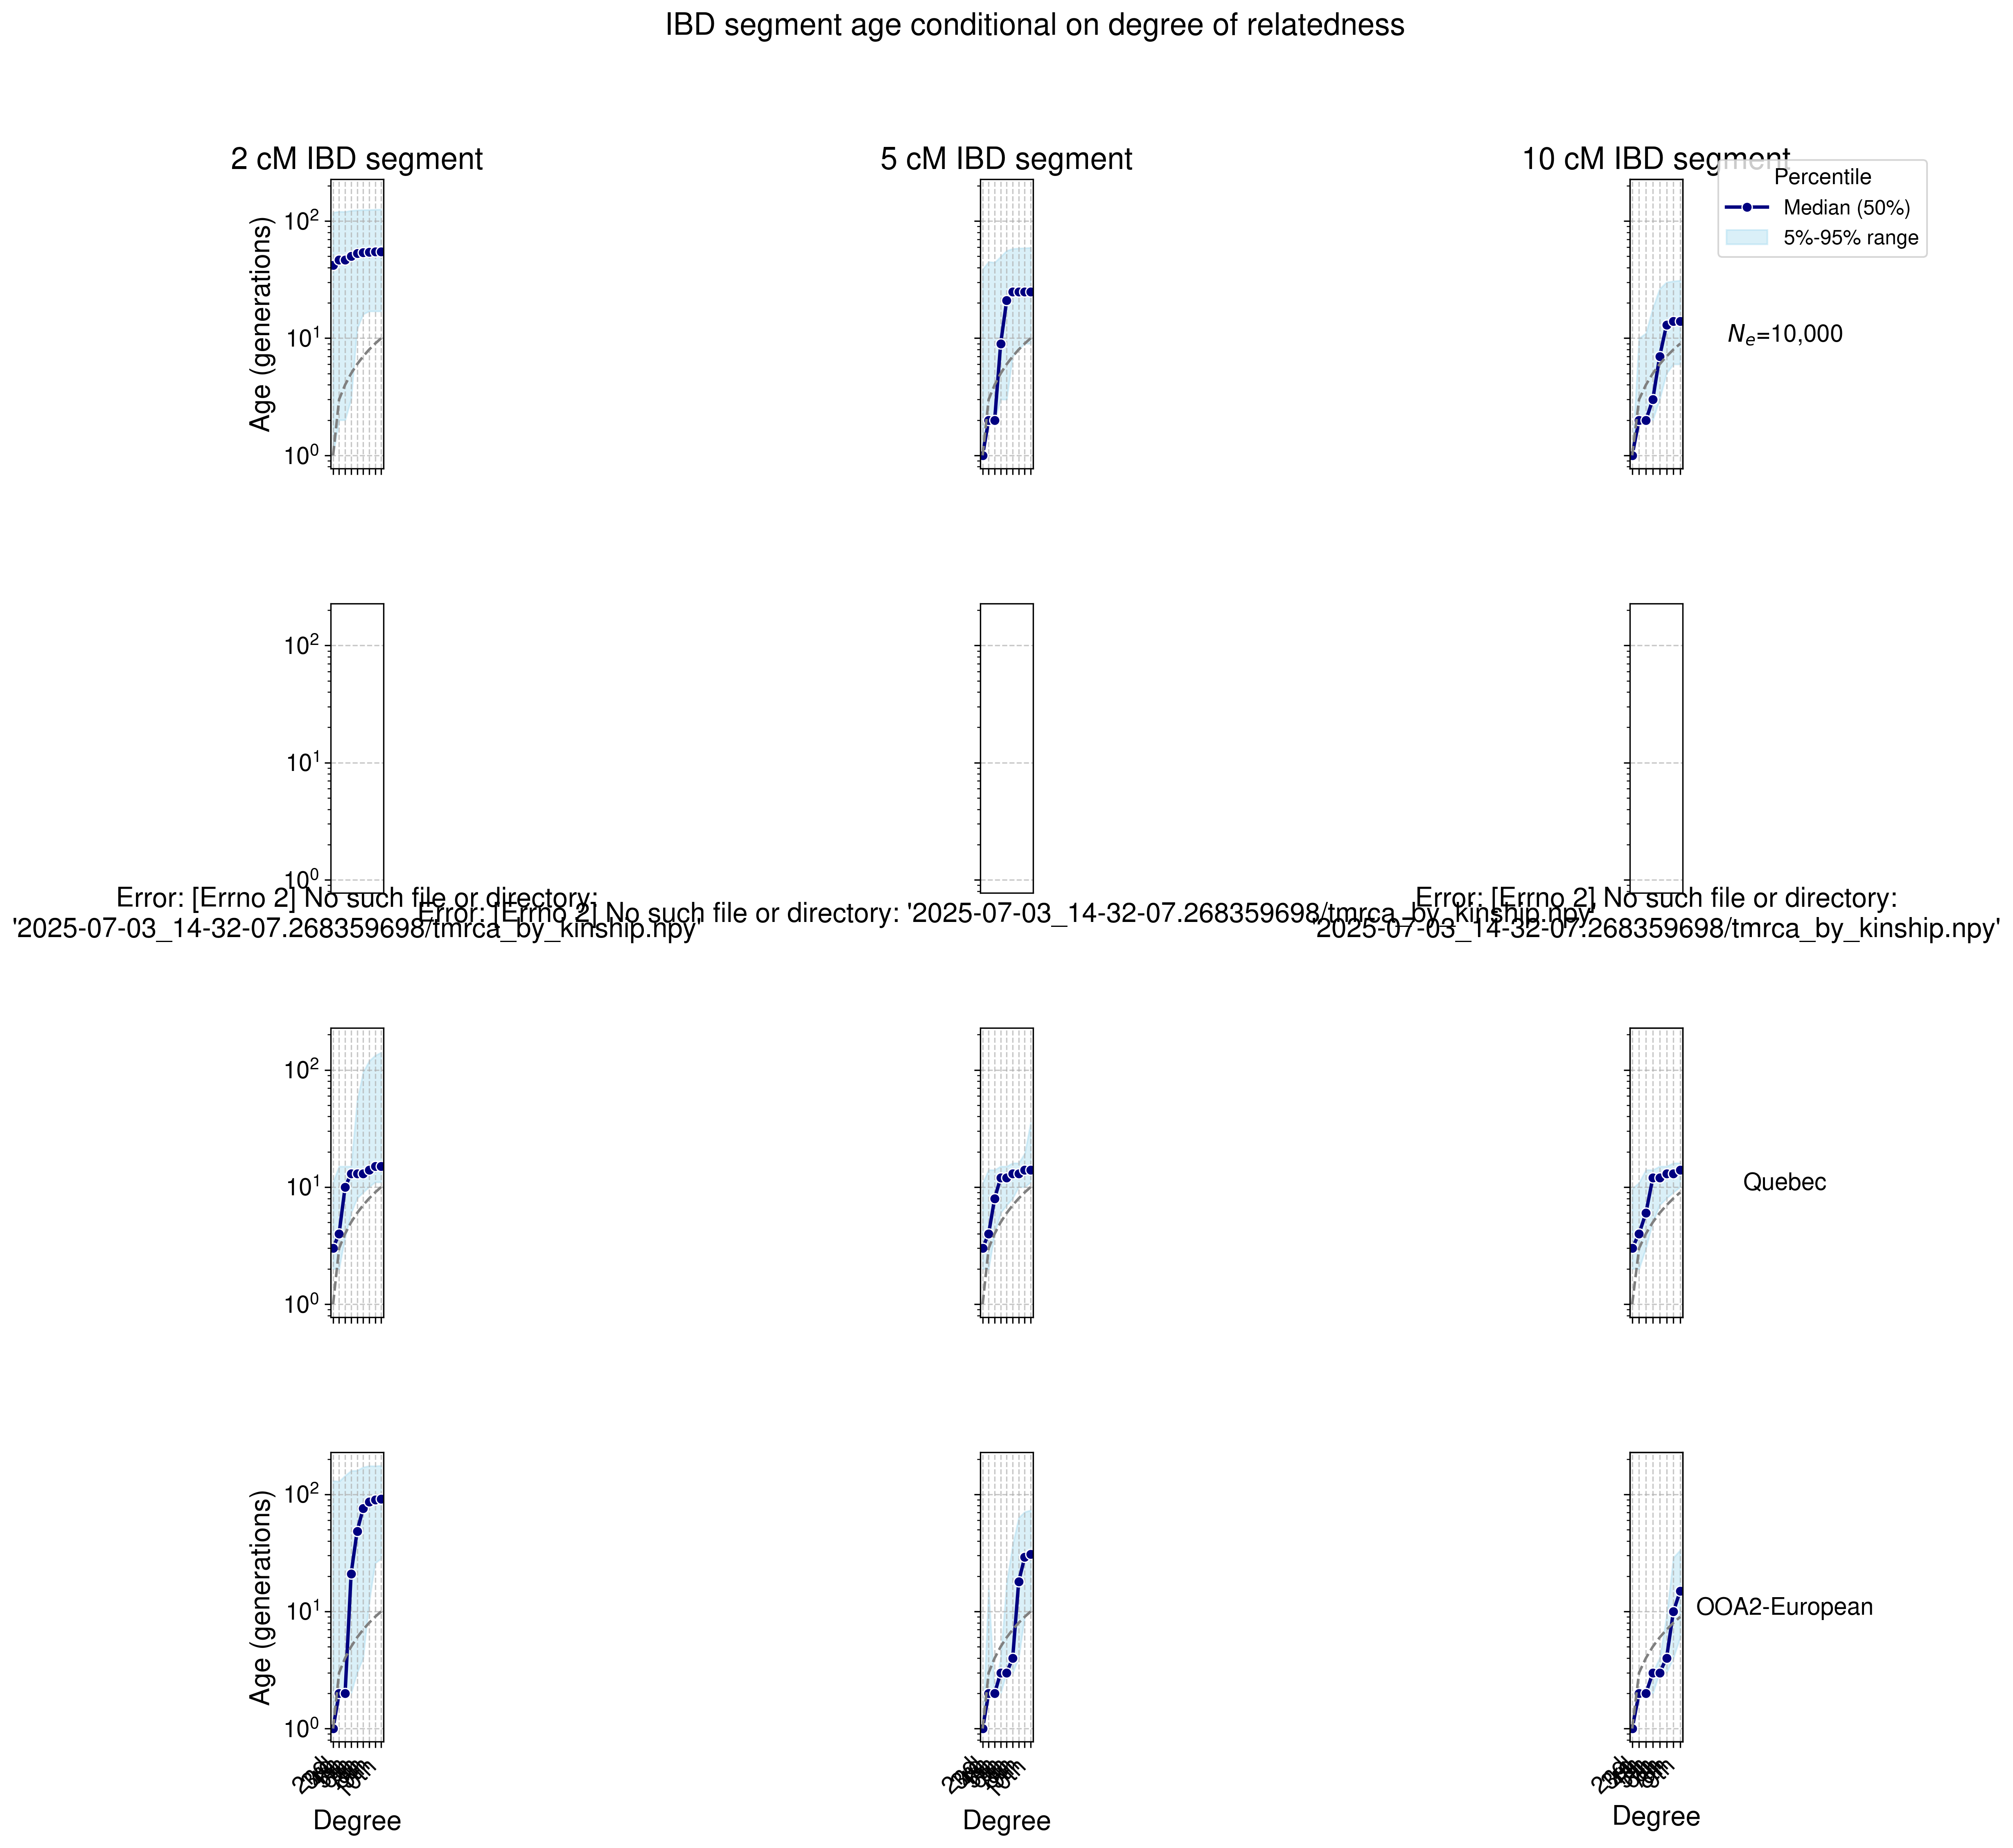

In [9]:
fig, axs = plot_tmrca_grid(
    paths=paths,
    l_list=[2, 5, 10],
    degrees=degrees,
    path_labels=path_labels,
    l_labels=["2 cM IBD segment", "5 cM IBD segment", "10 cM IBD segment"],
    skip_degrees=["11th", "1st"],
    use_log_scale=True,
    custom_order=sorted_degrees
)

plt.savefig(f"{path}/tmrca_by_kinship.png", dpi=600)

#### Purple nodes

/tmp/ipykernel_3920723/2448735370.py:74: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  plot_df = pd.concat(plot_df)
/users/cwilli50/.local/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/users/cwilli50/.local/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key

array([<Axes: title={'center': 'Segment length $l_1$ = 5 cM'}, xlabel='Segment length $l_2$ (cM)', ylabel='Empirical purple rate'>,
       <Axes: title={'center': 'Segment length $l_1$ = 10 cM'}, xlabel='Segment length $l_2$ (cM)'>],
      dtype=object)

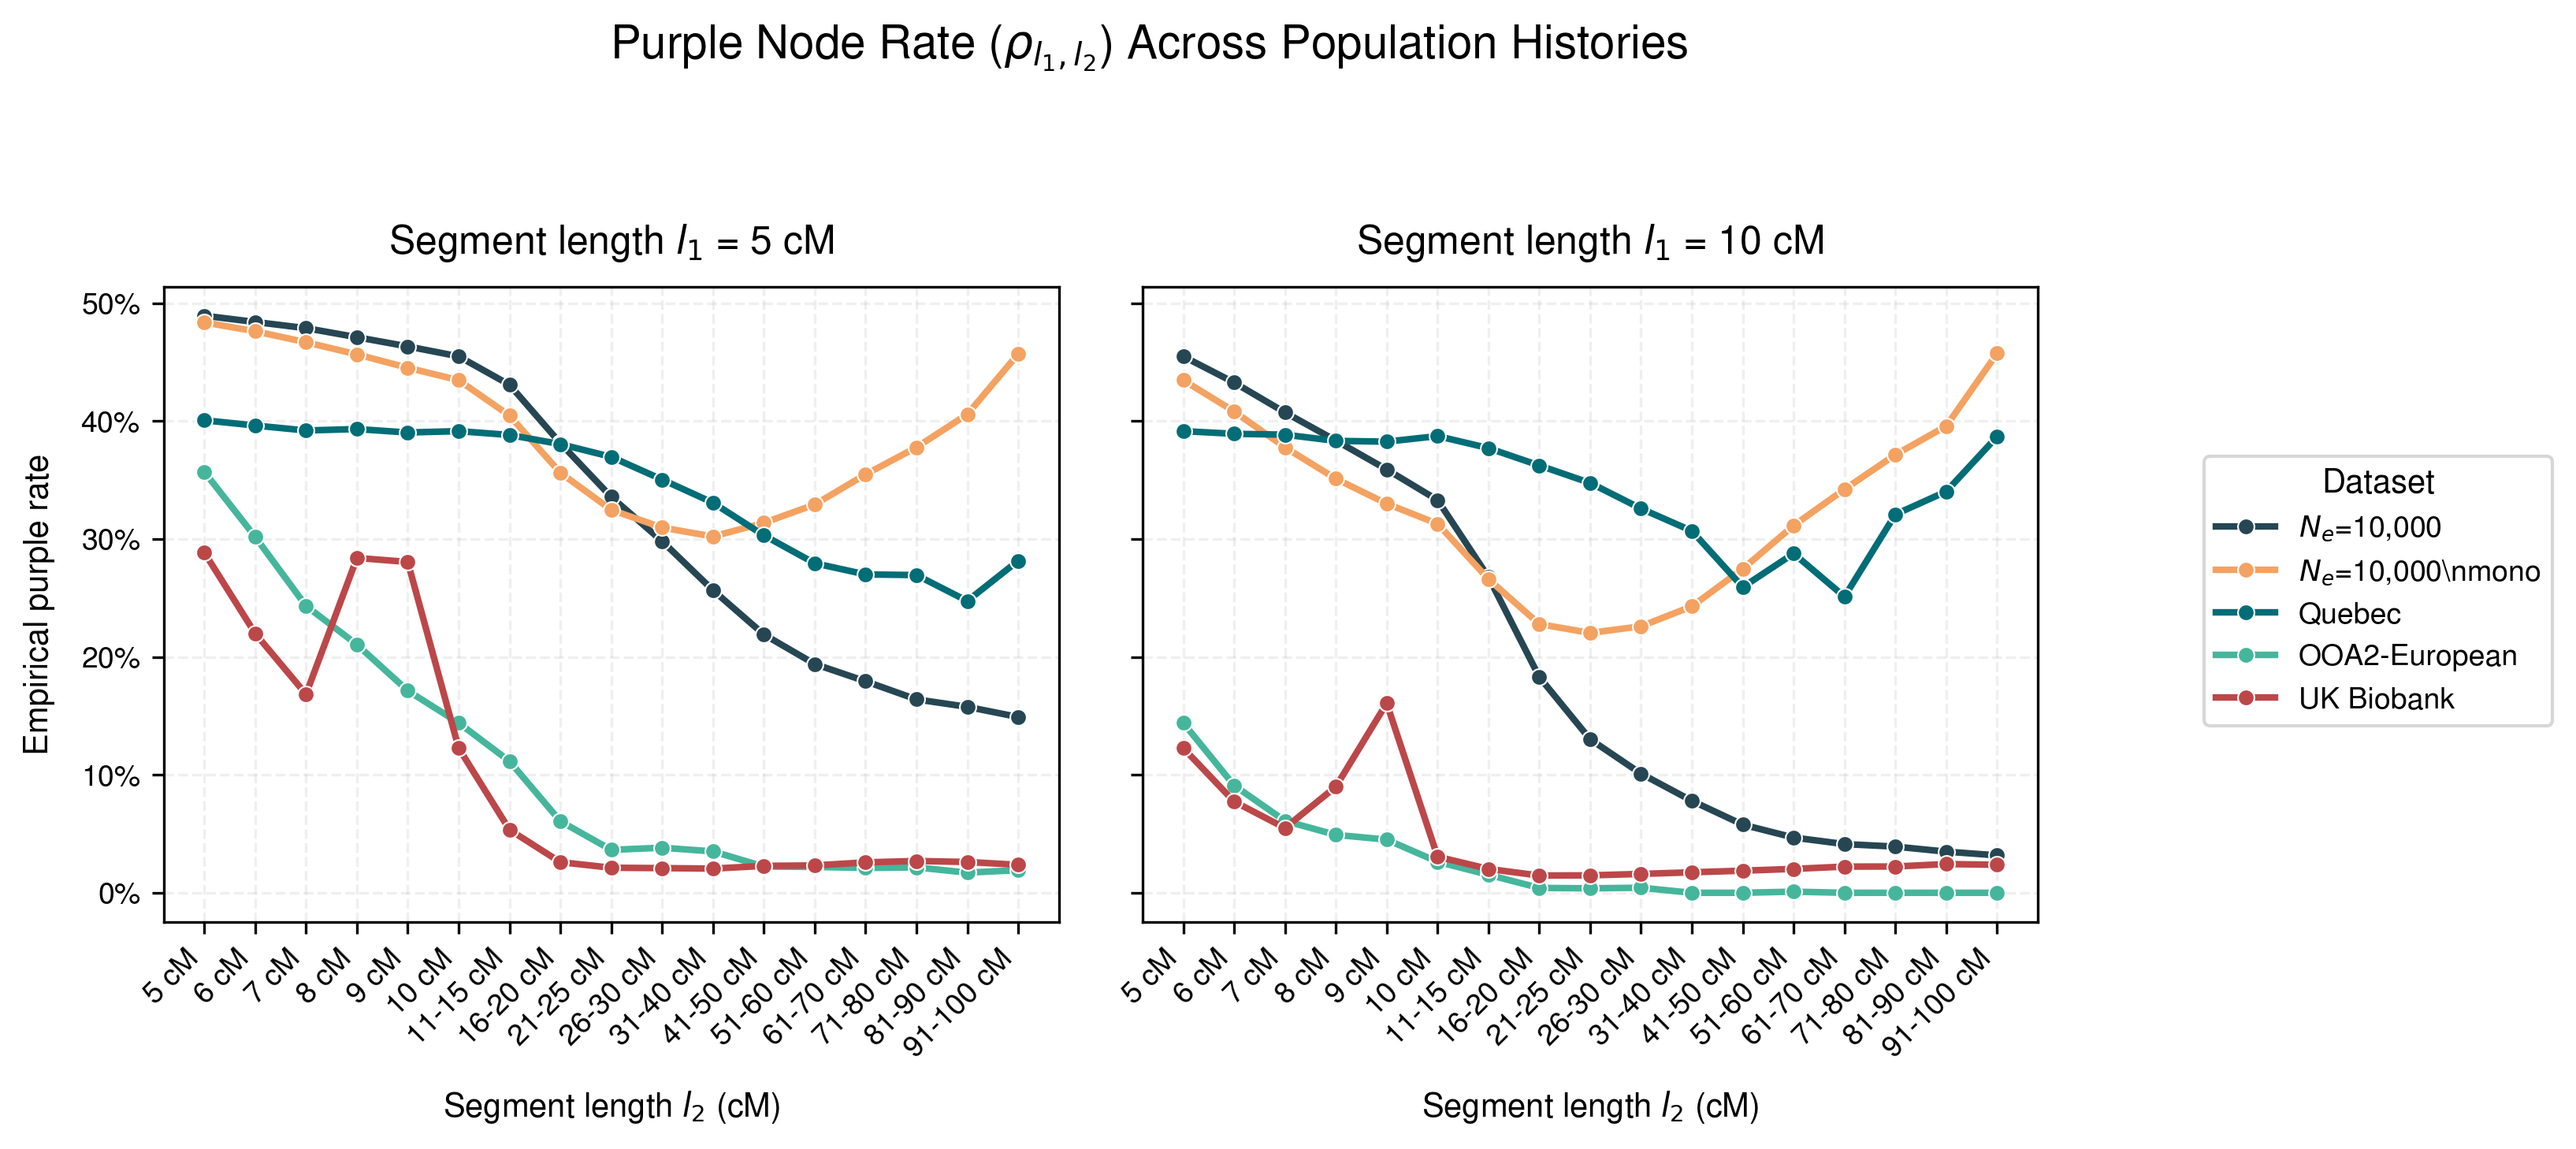

In [10]:
def plot_purple_rates_comparison(paths, labels, segment_ls=["(5,)", "(10,)"], figsize=(10, 5), save_path=None):
    """
    Creates a publication-quality figure with two subplots comparing purple rates for two different segment lengths.
    
    Parameters:
    -----------
    paths : list
        List of paths to data files
    labels : list
        List of labels for each dataset
    segment_ls : list, optional
        List of two segment lengths to compare
    figsize : tuple, optional
        Figure size (width, height) in inches
    save_path : str, optional
        Path to save the figure. If None, figure is displayed
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.gridspec import GridSpec
    
    # Validate input
    if len(segment_ls) != 2:
        raise ValueError("segment_ls must contain exactly 2 segment lengths")
    
    # Set up publication-quality figure with 2 columns, 1 row
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    gs = GridSpec(1, 2, figure=fig, wspace=0.3)
    
    # Define a high-contrast, publication-friendly color palette
    palette = [
    '#264653',  # Dark teal
    # '#2a9d8f',  # Turquoise
    # '#e9c46a',  # Mustard
    '#f4a261',  # Peach
    # '#e76f51',  # Coral
    # '#5e548e',  # Purple
    '#006d77',  # Deep aqua
    # '#83c5be',  # Seafoam
    '#45b69c',  # Mint
    '#bc4749'   # Burgundy
]
    
    # Process each segment length
    # axes = []
    for i, segment_l in enumerate(segment_ls):
        plot_df = []
        for path, label in zip(paths + ["uk_biobank"], labels + ["UK Biobank"]):
            if path == "uk_biobank":
                mat, lab = bin_purple(np.sum(np.load("uk_biobank/iter1.npy")[:,:,:1061,:], axis=2))
            else:
                mat, lab = stack_purple(path)
            idx = lab.index(segment_l)
            # Get the top half
            row = np.divide(mat[idx, idx:, 0], mat[idx, idx:, 1])
            tmp = pd.DataFrame({
                "purple_rate": row, 
                "segment": lab[idx:], 
                "label": label
            })
            plot_df.append(tmp)
            # Get the bottom half
            rows = []
            for lidx in range(3, idx):
                row = [np.divide(mat[lidx, idx, 0], mat[lidx, idx, 1])]
                row.extend([lab[lidx], label])
                rows.append(row)
            tmp = pd.DataFrame(rows, columns=["purple_rate", "segment", "label"])
            plot_df.append(tmp)

        plot_df = pd.concat(plot_df)
        
        # Process segment format for display
        plot_df["segment"] = plot_df.segment.apply(lambda x: x.strip("()").split(","))
        plot_df["segment"] = plot_df.segment.apply(lambda x: (x[0] if x[1]=="" else f"{x[0]}-{x[1].strip()}") + " cM")
        
        # Create ordered categorical for consistent ordering
        segment_order = sorted(list(set(plot_df.segment)), key=lambda x: int(x.split("-")[0]) if "-" in x else int(x.split(" ")[0]))
        plot_df["segment"] = pd.Categorical(plot_df["segment"], categories=segment_order, ordered=True)
        
        # Extract segment_l in clean format for title
        seg_l_clean = segment_l.strip("()").split(",")
        seg_l_display = seg_l_clean[0] if seg_l_clean[1] == "" else f"{seg_l_clean[0]}-{seg_l_clean[1].strip()}"
        
        # Create subplot
        # ax = fig.add_subplot(gs[0, i])
        ax = axes[i]
        # axes.append(ax)
        
        # Draw line plot
        sns.lineplot(
            data=plot_df, 
            x="segment", 
            y="purple_rate", 
            hue="label",
            palette=palette[:len(plot_df["label"].unique())],
            linewidth=2,
            marker='o',
            markersize=5,
            markeredgecolor='white',
            markeredgewidth=0.5,
            ax=ax
        )
        
        # Improve styling
        ax.grid(alpha=0.2, linestyle='--')
        
        # Add subplot title and labels
        prob = r"$\rho_{l_%s,l_2}$" % seg_l_display
        ax.set_title(f"Segment length $l_1$ = {seg_l_display} cM", fontsize=12, pad=10)
        ax.set_xlabel(r"Segment length $l_2$ (cM)", fontsize=10, labelpad=8)
        
        if i == 0:  # Only add y-label to the first subplot
            ax.set_ylabel(f"Empirical purple rate", fontsize=10, labelpad=8)
        else:
            ax.set_ylabel("")
        
        # Format axes
        ax.tick_params(axis='both', labelsize=9)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        
        # Format y-axis to show percentages
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
        
        # Add annotations for maximum values
        # for label_name in plot_df["label"].unique():
        #     label_data = plot_df[plot_df["label"] == label_name]
        #     max_idx = label_data["purple_rate"].idxmax()
            
        #     # Add annotation
        #     ax.annotate(
        #         f'{label_data["purple_rate"].max():.2f}',
        #         xy=(label_data.loc[max_idx, "segment"], label_data.loc[max_idx, "purple_rate"]),
        #         xytext=(-10, 0),
        #         textcoords='offset points',
        #         ha='right',
        #         fontsize=7,
        #         arrowprops=dict(arrowstyle='-|>', connectionstyle='arc3,rad=.2', color='gray')
        #     )
    
    # Put legend outside the second subplot
    handles, labels = axes[1].get_legend_handles_labels()
    axes[1].get_legend().remove()
    fig.legend(
        handles, 
        labels,
        title="Dataset",
        title_fontsize=10,
        fontsize=9,
        loc='center right', 
        bbox_to_anchor=(1.1, 0.5),
        frameon=True,
        framealpha=0.9,
        edgecolor='lightgray'
    )
    axes[0].get_legend().remove()
    
    # Add a super title for the entire figure
    fig.suptitle(r"Purple Node Rate ($\rho_{l_1,l_2}$) Across Population Histories", fontsize=14, y=0.98)
    
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # Adjust to leave room for the legend
    
    # Save or display the figure
    if save_path:
        plt.savefig(save_path, dpi=500, bbox_inches='tight')
    else:
        plt.show()
        
    return axes

plot_purple_rates_comparison(paths, labels, save_path=f"{path}/purple_node_l5_l10.png")

In [11]:
def plot_ne_estimates(data_dict_list, truth_df_list=None, plot_labels=None, figsize=(12, 10), 
                     xlim=(0, 50), log_scale=True, colors=None, legend_ncol=4, one_row_legend=False, 
                     color_map=None):
    """
    Plot multiple effective population size estimates with confidence intervals in a grid layout.
    
    Parameters:
    -----------
    data_dict_list : list of dict
        List of dictionaries where keys are labels and values are lists of DataFrames.
        Each DataFrame should have 'GEN' and 'NE' columns.
    truth_df_list : list of pd.DataFrame, optional
        List of DataFrames, each with 'GEN' and 'NE' columns representing the true values.
        Can contain None values for plots without truth data.
    plot_labels : list of str, optional
        List of labels for each subplot. If None, uses default labels.
    figsize : tuple, optional
        Overall figure size (width, height)
    xlim : tuple, optional
        x-axis limits (min, max)
    log_scale : bool, optional
        Whether to use log scale for y-axis
    colors : list, optional
        List of colors for each dataset. If None, uses a predefined color palette
    legend_ncol : int, optional
        Number of columns in the combined legend below the plots
    one_row_legend : bool, optional
        If True, forces all legend items into a single row.
        If False, places "Truth" on a second row (if present)
    color_map : dict, optional
        Dictionary mapping keys ('filtered', 'unfiltered', 'related', 'unrelated') to color values.
        If provided, overrides the default color mapping
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    axs : list of matplotlib.axes.Axes
        List of axes objects
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns
    import math

    plt.rcParams.update({
            'font.family': 'sans-serif',
            'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
            'font.size': 10,
            'axes.labelsize': 11,
            'axes.titlesize': 12,
            'xtick.labelsize': 9,
            'ytick.labelsize': 9,
            'legend.fontsize': 9,
            'figure.titlesize': 13
        })
    
    
    # Validate inputs
    n_plots = len(data_dict_list)
    if truth_df_list is None:
        truth_df_list = [None] * n_plots
    elif len(truth_df_list) != n_plots:
        raise ValueError("truth_df_list must have the same length as data_dict_list")
    
    if plot_labels is None:
        plot_labels = [f"Plot {i+1}" for i in range(n_plots)]
    elif len(plot_labels) != n_plots:
        raise ValueError("plot_labels must have the same length as data_dict_list")
    
    # Define marker styles for different lines
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h', '8']
    # Define line styles
    line_styles = ['-', '--', '-.', ':']
    
    # Calculate grid dimensions (as close to square as possible)
    n_rows = int(np.ceil(np.sqrt(n_plots)))
    n_cols = int(np.ceil(n_plots / n_rows))
    
    # Create a figure with grid layout
    fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize, 
                           sharex=False, constrained_layout=False)
    
    # Convert axs to a flattened array for easier indexing
    if n_rows == 1 and n_cols == 1:
        axs = np.array([axs])
    axs = axs.flatten()
    
    # Process each plot
    for plot_idx, (data_dict, truth_df, plot_label) in enumerate(zip(data_dict_list, truth_df_list, plot_labels)):
        if plot_idx >= len(axs):
            break
            
        ax = axs[plot_idx]
        
        # Generate colors if not provided
        if colors is None:
            # Default color palette as a dictionary for consistent mapping
            default_colors = {
                'filtered': '#66c2a5',    # Teal green - sophisticated but approachable
                'unfiltered': '#fc8d62',  # Coral orange - energetic and bold
                'related': '#8da0cb',     # Periwinkle blue - creative yet professional
                'unrelated': '#e78ac3'    # Rose pink - expressive and memorable
            }
            
            # # Use user-provided color map if available
            # if color_map is not None:
            #     default_colors.update(color_map)
            
            # # Map each key in data_dict to a color
            # plot_colors = []
            # for key in data_dict.keys():
            #     # Check if any of our defined keys are in the label
            #     found_match = False
            #     for color_key, color_value in default_colors.items():
            #         if color_key in key.lower():
            #             plot_colors.append(color_value)
            #             found_match = True
            #             break
                
            #     # If no match found, use a default color from seaborn
            #     if not found_match:
            #         # Get a color from seaborn's palette
            #         fallback_colors = sns.color_palette("deep", len(data_dict))
            #         idx = len(plot_colors) % len(fallback_colors)
                    # plot_colors.append(fallback_colors[idx])
        else:
            # If colors are provided directly, use them
            plot_colors = colors
        
        # Extract common parts from labels for title
        title_strs = []
        tmp = []
        for label in data_dict.keys():
            tmp.extend(label.split("\n"))
        for i in tmp:
            if tmp.count(i) == len(data_dict.keys()):
                title_strs.append(i)
        common_title = " | ".join(list(set(title_strs)))
        
        # Set the subplot title
        if common_title:
            full_title = f"{plot_label}\n{common_title}"
        else:
            full_title = plot_label
        
        # Plot each dataset in the current subplot
        for i, (label, dfs) in enumerate(data_dict.items()):
            color = default_colors[label]
            # Convert list of DataFrames to 3D array
            data_array = np.array([df['NE'].values for df in dfs])

            # Calculate statistics
            mean = np.mean(data_array, axis=0)
            
            # Get generations (using first DataFrame as reference)
            generations = dfs[0]['GEN']
            
            # Create line style
            marker = markers[i % len(markers)]  # Cycle through markers
            linestyle = line_styles[i % len(line_styles)]  # Cycle through line styles
            
            # Plot mean with line style
            ax.plot(generations, mean, 
                   label="\n".join([i for i in label.split("\n") if i not in title_strs]), 
                   color=color, 
                   linewidth=2.5,
                   linestyle=linestyle)

            # Add confidence interval if more than one sample
            if len(data_array) > 1:
                percentile_5 = np.percentile(data_array, 5, axis=0)
                percentile_95 = np.percentile(data_array, 95, axis=0)
                ax.fill_between(generations, percentile_5, percentile_95,
                              color=color, alpha=0.15)
        
        # Plot truth data if provided
        if truth_df is not None:
            ax.plot(truth_df['GEN'], truth_df['NE'], 
                    color='black',
                    linestyle="--",
                    label='Truth',
                    linewidth=2)
                    
            # if np.std(truth_df["NE"]) == 0:
            #     ax.axvline(x=np.log(truth_df.iloc[0]["NE"]) / np.log(2), 
            #               linestyle="--", color="black", linewidth=1.5,
            #               label=r"$log_2N_e$")
            #     ax.axvline(x=1.77 * np.log(truth_df.iloc[0]["NE"]) / np.log(2), 
            #               linestyle=":", color="black", linewidth=2,
            #               label=r"$1.77 \times log_2N_e$")

        # Set axis properties
        ax.set_xlim(xlim)
        if log_scale:
            ax.set_yscale('log')
        
        ax.set_title(full_title, pad=20)
        ax.grid(True, alpha=0.2)
        
        # Add x-label to all subplots
        ax.set_xlabel('Generation')
        
        # Add y-label to leftmost subplots
        if plot_idx % n_cols == 0:
            ax.set_ylabel('Effective Population Size')
        
        # Don't add individual legends to subplots
    
    # Hide any unused subplots
    for i in range(n_plots, len(axs)):
        axs[i].set_visible(False)
    
    # Collect all unique labels and handles for the combined legend
    all_handles = []
    all_labels = []
    truth_handle = None
    truth_label = None
    used_labels = set()
    
    for plot_idx in range(n_plots):
        ax = axs[plot_idx]
        handles, labels = ax.get_legend_handles_labels()
        
        for handle, label in zip(handles, labels):
            # Separate the Truth label and handle (just take the first occurrence)
            if label == 'Truth' and truth_handle is None:
                truth_handle = handle
                truth_label = label
                used_labels.add(label)  # Mark as used to prevent duplicates
            elif label != 'Truth' and label not in used_labels:
                all_handles.append(handle)
                all_labels.append(label)
                used_labels.add(label)
    
    # Add a single legend at the bottom of the figure
    fig.subplots_adjust(bottom=0.18)  # Make room for the legend at the bottom
    
    if all_handles:
        # Option 1: All in one row (including Truth if present)
        if one_row_legend or (truth_handle is None):
            # Put everything in one row
            if truth_handle is not None:
                all_handles.append(truth_handle)
                all_labels.append(truth_label)
            
            fig.legend(all_handles, all_labels, 
                     loc='lower center', 
                     bbox_to_anchor=(0.5, 0.02),
                     ncol=len(all_handles),  # Force one row
                     framealpha=1.0,
                     borderaxespad=0.)
        
        # Option 2: Truth on second row
        else:
            # First row without Truth
            fig.legend(all_handles, all_labels, 
                     loc='lower center', 
                     bbox_to_anchor=(0.5, 0.07),
                     ncol=min(len(all_handles), legend_ncol),
                     framealpha=1.0,
                     borderaxespad=0.)
            
            # Second row with just Truth if present
            if truth_handle is not None:
                fig.legend([truth_handle], [truth_label],
                         loc='lower center',
                         bbox_to_anchor=(0.5, 0.02),
                         ncol=1,
                         framealpha=1.0,
                         borderaxespad=0.)
    
    # Adjust spacing between subplots
    plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave room for the legend at the bottom
    
    return fig, axs

In [12]:
import os
import glob
import yaml
from plot import get_truth

data_dict_list, truth_df_list, plot_labels = [], [], []

for p, lab in path_labels:
    try:
        truth_df = get_truth(yaml.safe_load(open(p + "/args.yaml")))
    except AttributeError:
        truth_df = get_truth(yaml.safe_load(open(paths[-1] + "/args.yaml")))
        truth_df = truth_df[truth_df.GEN>17]

    data_dict = {}
    for r in ["unrelated", "related", "filtered", "unfiltered"]:
        if lab == "Quebec" and r == "unrelated":
            continue
        if not os.path.exists(f"{p}/{r}_ibdne/"):
            print(p, r)
            continue
        df_list = [pd.read_csv(ne, delim_whitespace=True) for ne in glob.glob(f"{p}/{r}_ibdne/*.ne")]
        data_dict[r] = df_list

    data_dict_list.append(data_dict)
    truth_df_list.append(truth_df)
    plot_labels.append(lab)


Getting custom demographic model


/tmp/ipykernel_3920723/2281217427.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_list = [pd.read_csv(ne, delim_whitespace=True) for ne in glob.glob(f"{p}/{r}_ibdne/*.ne")]
/tmp/ipykernel_3920723/2281217427.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_list = [pd.read_csv(ne, delim_whitespace=True) for ne in glob.glob(f"{p}/{r}_ibdne/*.ne")]
/tmp/ipykernel_3920723/2281217427.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_list = [pd.read_csv(ne, delim_whitespace=True) for ne in glob.glob(f"{p}/{r}_ibdne/*.ne")]
/tmp/ipykernel_3920723/2281217427.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``

/tmp/ipykernel_3920723/2281217427.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_list = [pd.read_csv(ne, delim_whitespace=True) for ne in glob.glob(f"{p}/{r}_ibdne/*.ne")]
/tmp/ipykernel_3920723/2281217427.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_list = [pd.read_csv(ne, delim_whitespace=True) for ne in glob.glob(f"{p}/{r}_ibdne/*.ne")]
/tmp/ipykernel_3920723/2281217427.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_list = [pd.read_csv(ne, delim_whitespace=True) for ne in glob.glob(f"{p}/{r}_ibdne/*.ne")]
/tmp/ipykernel_3920723/2281217427.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``

Getting custom demographic model
2025-07-03_14-32-07.268359698 related
2025-07-03_14-32-07.268359698 filtered
2025-07-03_14-32-07.268359698 unfiltered
Getting custom demographic model
Getting custom demographic model


/tmp/ipykernel_3920723/2281217427.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_list = [pd.read_csv(ne, delim_whitespace=True) for ne in glob.glob(f"{p}/{r}_ibdne/*.ne")]
/tmp/ipykernel_3920723/2281217427.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_list = [pd.read_csv(ne, delim_whitespace=True) for ne in glob.glob(f"{p}/{r}_ibdne/*.ne")]
/tmp/ipykernel_3920723/2281217427.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_list = [pd.read_csv(ne, delim_whitespace=True) for ne in glob.glob(f"{p}/{r}_ibdne/*.ne")]
/tmp/ipykernel_3920723/2281217427.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``

Getting custom demographic model


/tmp/ipykernel_3920723/2281217427.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_list = [pd.read_csv(ne, delim_whitespace=True) for ne in glob.glob(f"{p}/{r}_ibdne/*.ne")]
/tmp/ipykernel_3920723/2281217427.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_list = [pd.read_csv(ne, delim_whitespace=True) for ne in glob.glob(f"{p}/{r}_ibdne/*.ne")]
/tmp/ipykernel_3920723/2281217427.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_list = [pd.read_csv(ne, delim_whitespace=True) for ne in glob.glob(f"{p}/{r}_ibdne/*.ne")]
/tmp/ipykernel_3920723/2281217427.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``

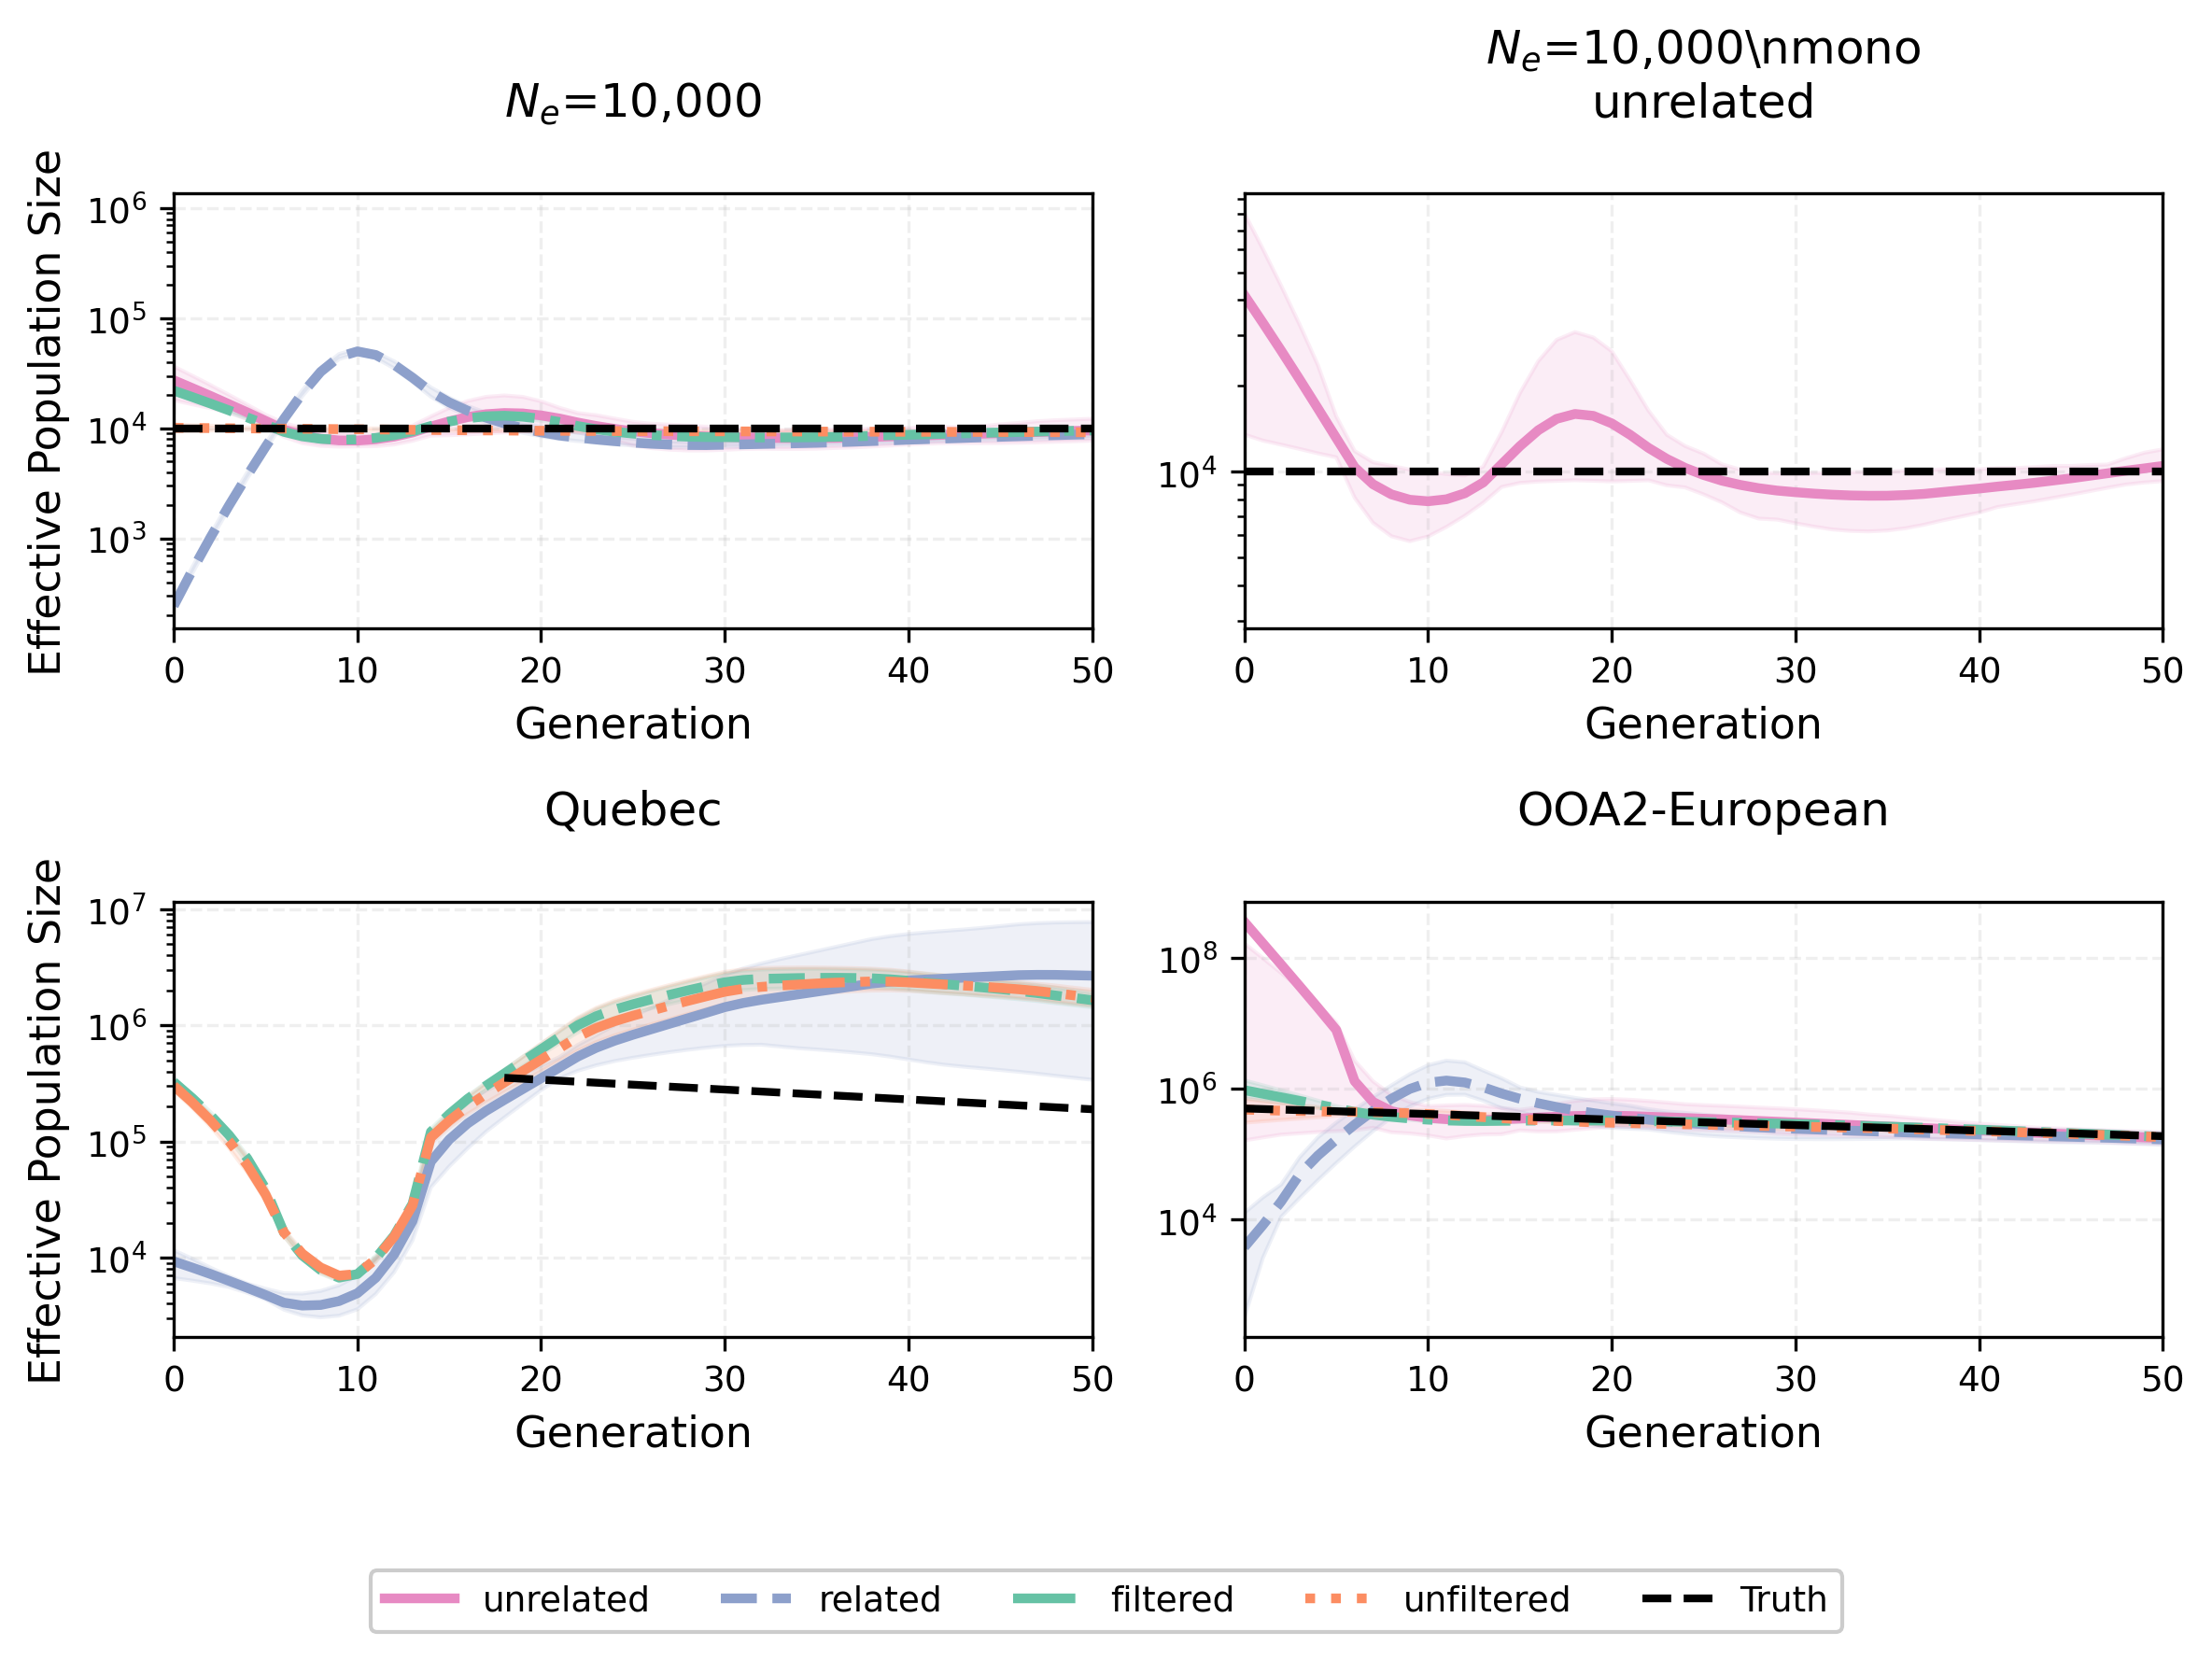

In [13]:
plot_ne_estimates(data_dict_list, truth_df_list, plot_labels, figsize=(8, 6), 
                     xlim=(0, 50), log_scale=True, colors=None, one_row_legend=True)

plt.savefig(f"{path}/ibdne_results.png", dpi=500)

In [14]:
from analysis_tools import tmrca_ne, load_ibd

def load_ibd_by_pair(path, iter_n):

    ibd_df = load_ibd(path, iter_n)

    ibd_df = ibd_df[ibd_df.tmrca.apply(len)==1]

    pairs = {}
    for pair, pair_df in ibd_df.groupby([0, 2]):
        tmrca = min(ibd_df.tmrca.apply(lambda x: x[0]))
        if tmrca > 10:
            continue
        pairs[pair] = (pair_df, tmrca)

    return pairs

def ne_tmrca_dataframe(path, iter_n, max_g=100):

    demo = yaml_arg(path, ("custom_demo", "object"))

    tmrca_df = tmrca_ne(demo)

    tmrca_dict = {row["length"]: row["gen"] for _,row in tmrca_df.iterrows()}

    pair_dict = load_ibd_by_pair(path, iter_n)

    dfs = []
    for pair, (pair_df, tmrca) in pair_dict.items():
        pair_df["tmrca"] = pair_df[7].apply(lambda x: tmrca_dict[int(x)])
        pair_df["pair_tmrca"] = tmrca
        dfs.append(pair_df)

    print(iter_n)

    return pd.concat(dfs)


# ne_tmrca_dataframe(paths[0], 1)

In [15]:
df = load_ibd(paths[-1], 1)

/oscar/data/sramacha/cwilli50/chapter3/analysis_tools.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ibd_df = pd.read_csv(f"{path}/iter{iter_n}.ibd.gz", delim_whitespace=True, header=None).drop_duplicates()


In [16]:
df = df[df.tmrca.apply(len)==1]

pairs = {}
for pair, pair_df in df.groupby([0, 2]):
    tmrca = min(pair_df.tmrca.apply(lambda x: x[0]))
    if tmrca > 10:
        continue
    pairs[pair] = (pair_df, tmrca)

In [17]:
demo = yaml_arg(paths[-1], ("custom_demo", "object"))

tmrca_df = tmrca_ne(demo)


tmrca_dict = {row["length"]: row["gen"] for _,row in tmrca_df.iterrows()}
dfs = []
for pair, (pair_df, tmrca) in pairs.items():
    pair_df["pair_tmrca"] = tmrca
    dfs.append(pair_df)

plot_df = pd.concat(dfs)

In [18]:
plot_df["segment_age"] = plot_df[7].apply(int).apply(lambda x: tmrca_dict[x])

<Axes: xlabel='segment_age', ylabel='Count'>

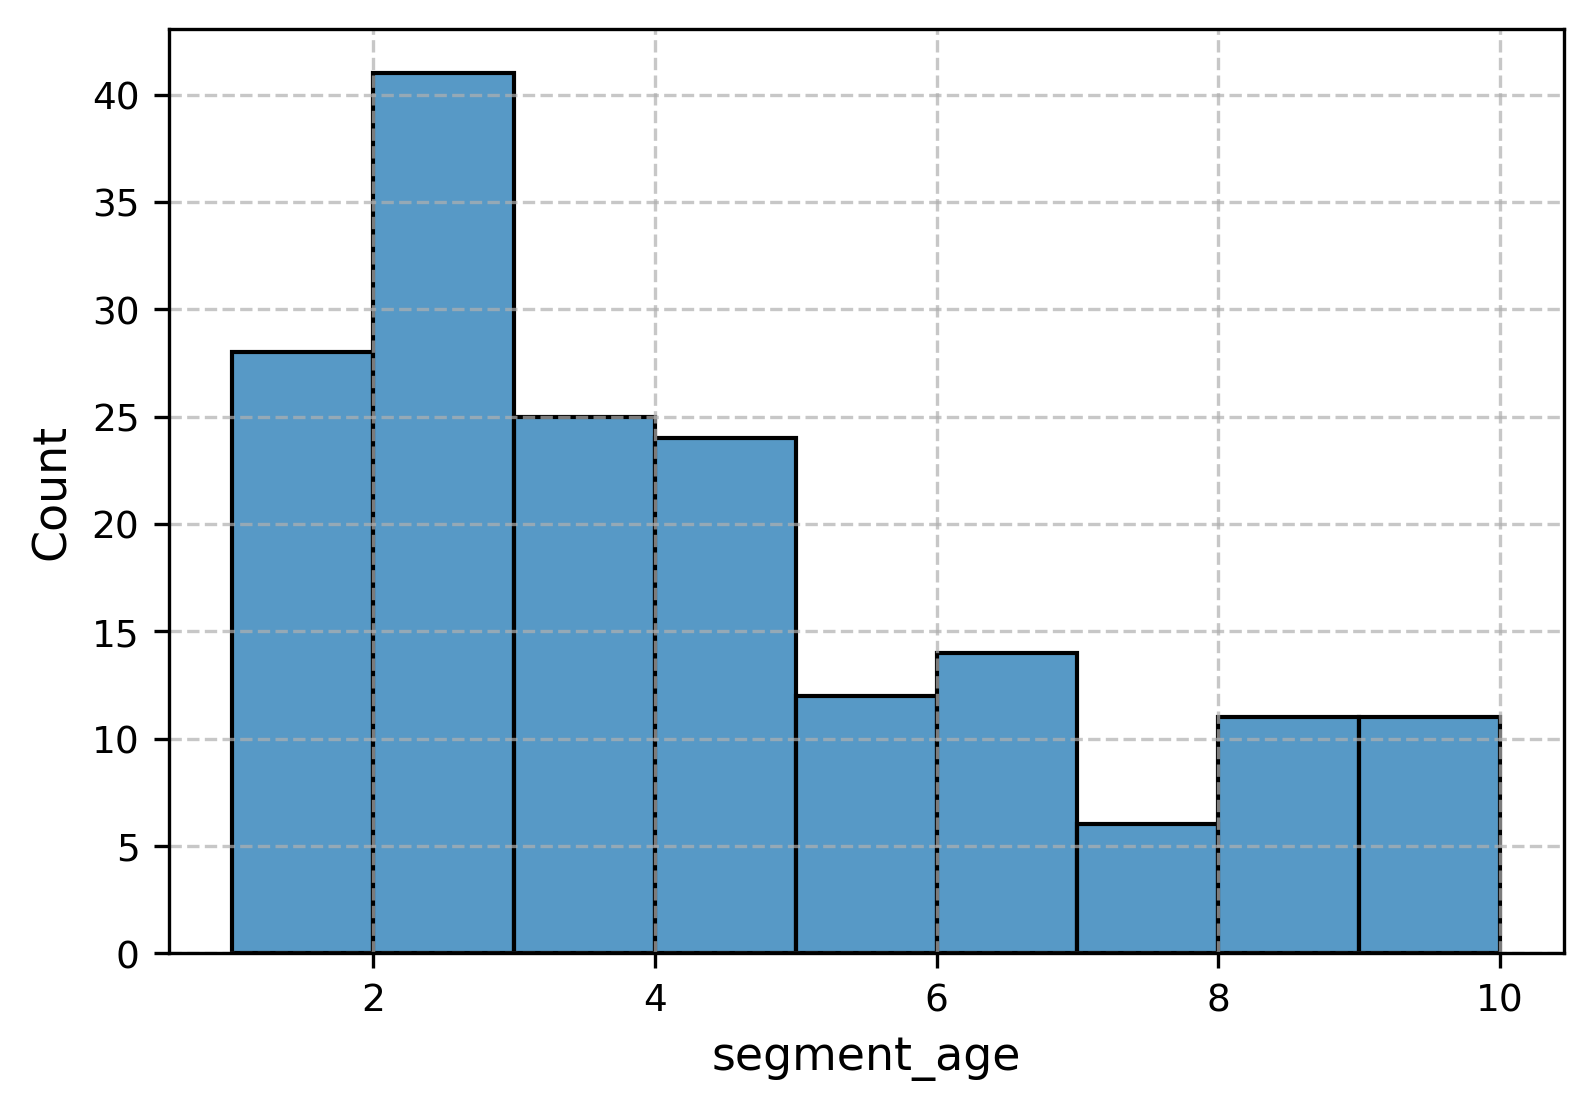

In [19]:
sns.histplot(data=plot_df[(plot_df.pair_tmrca==1)&(plot_df.segment_age<=10)], x="segment_age")

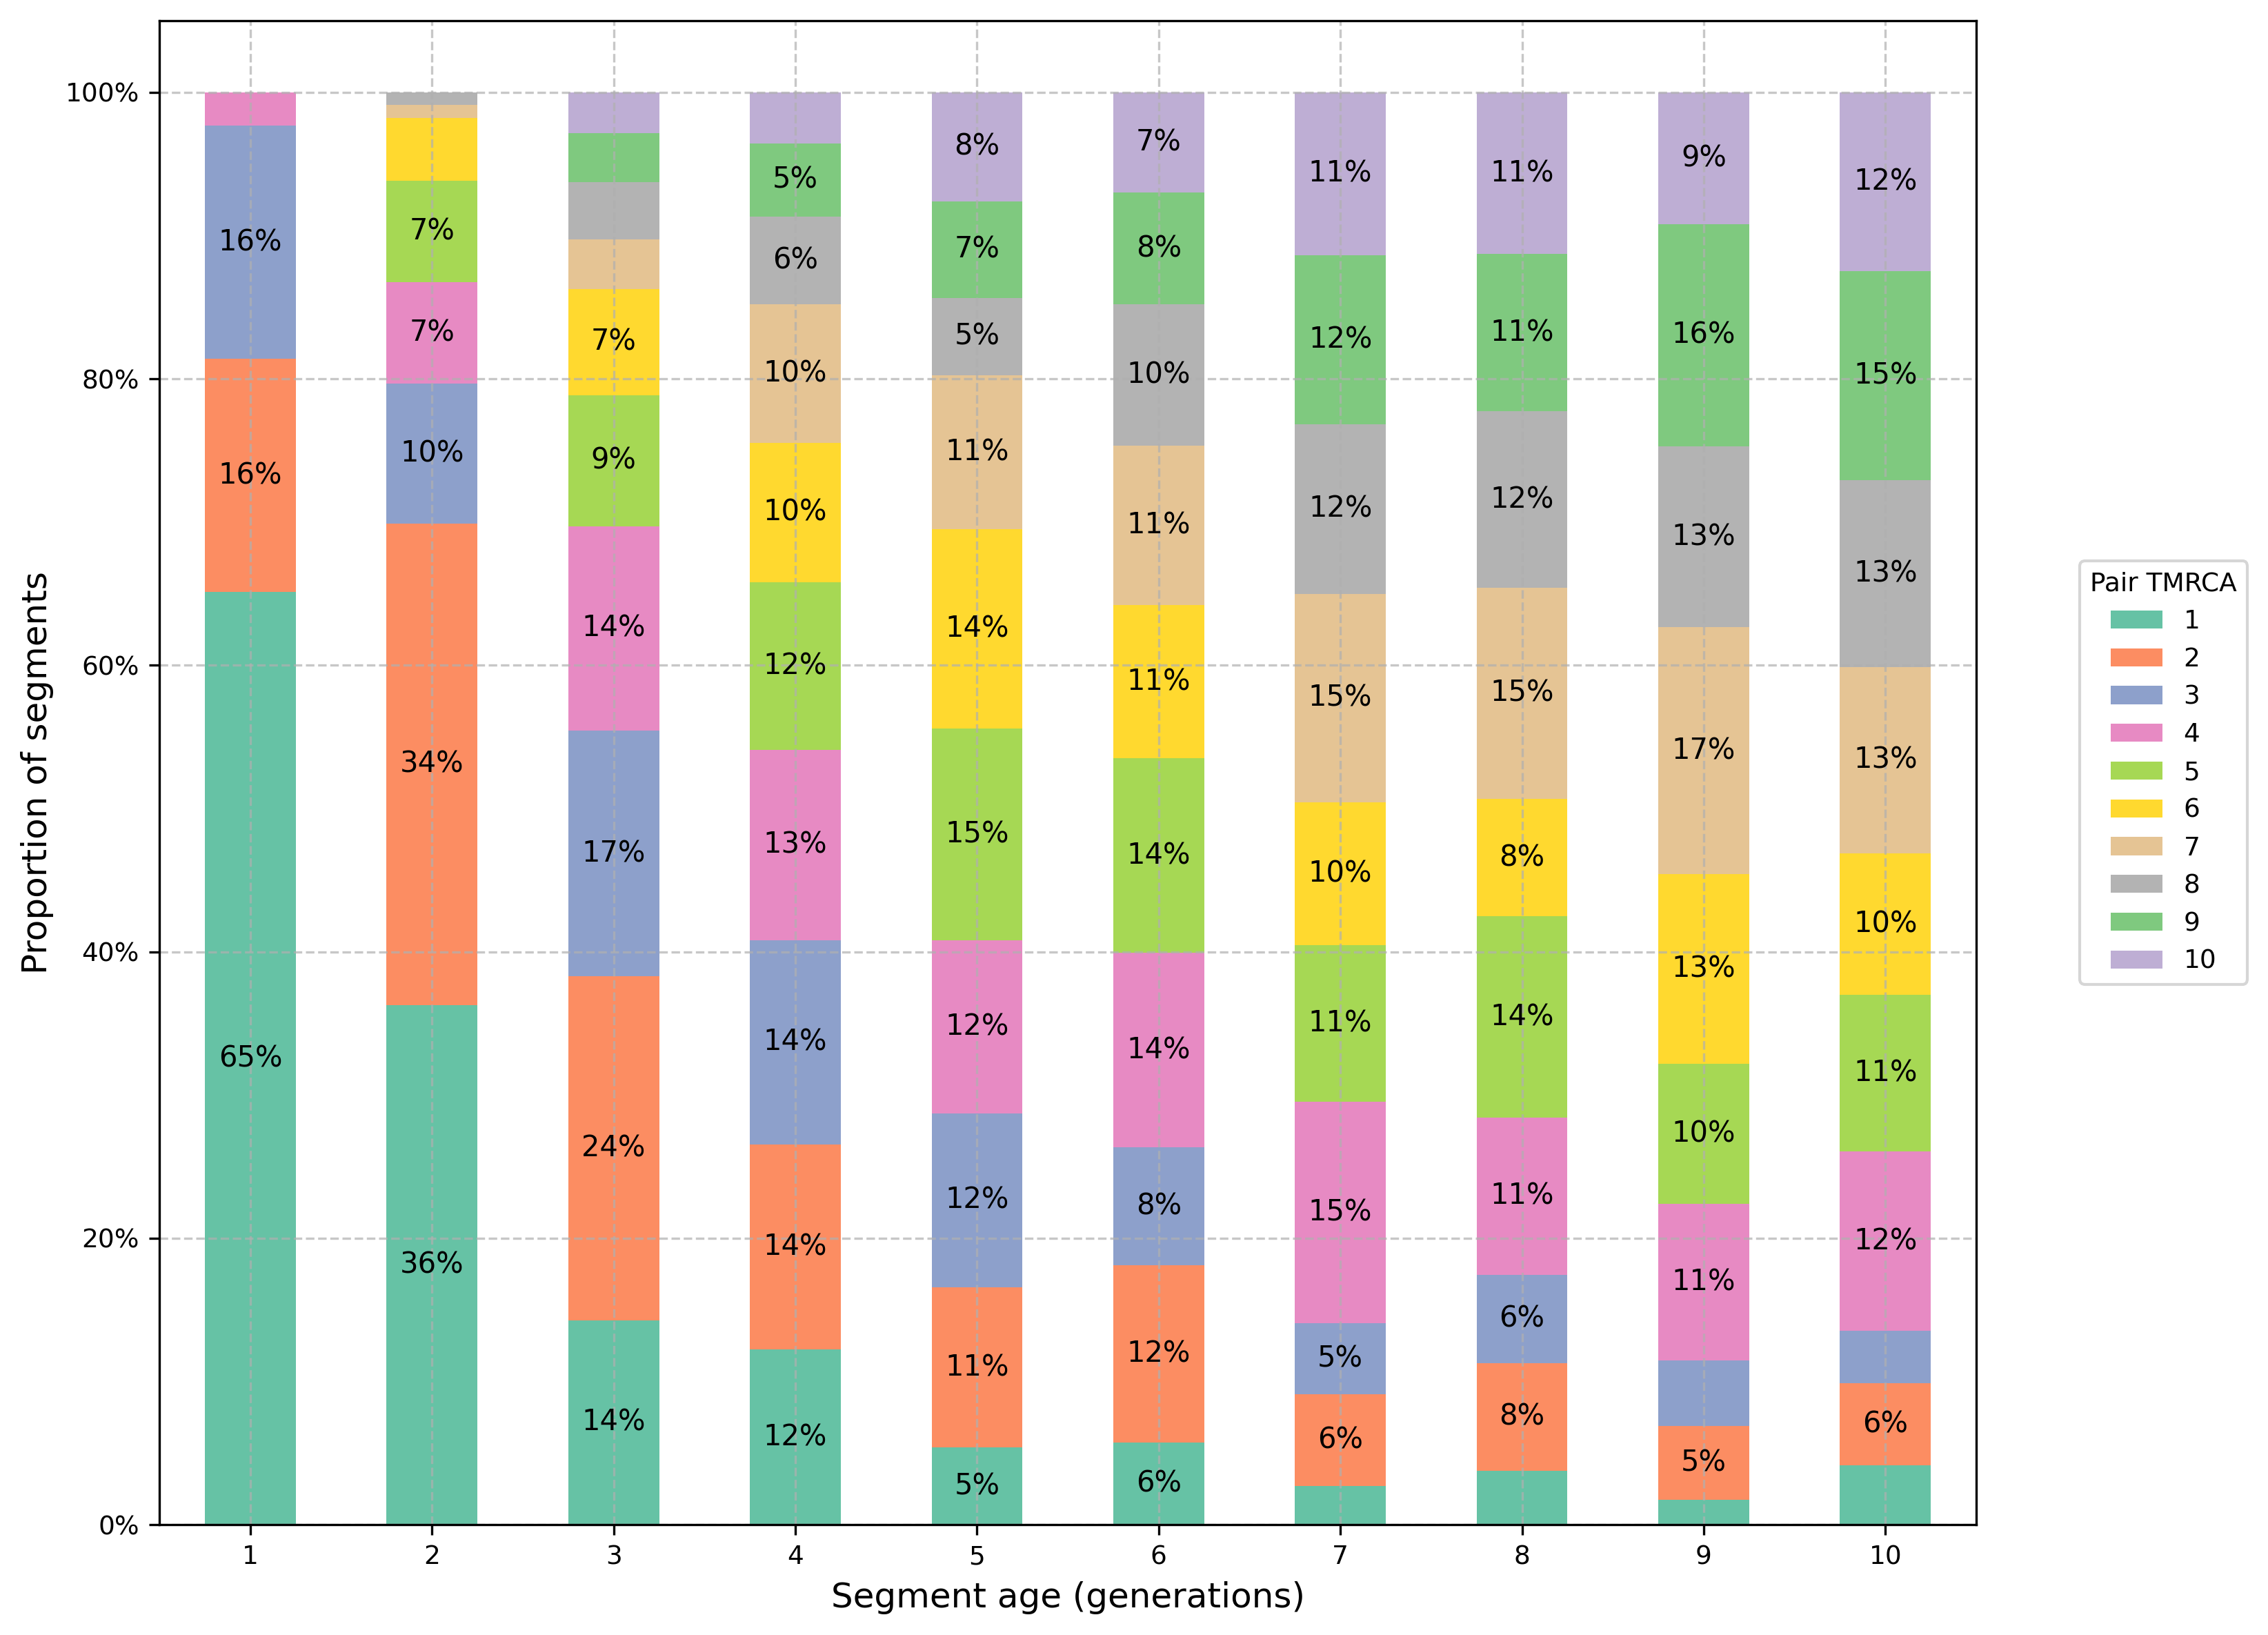

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def create_proportional_stacked_barplot(plot_df):
    """
    Create a proportional stacked barplot showing the distribution of pair_tmrca values (1-10)
    for each segment age (1-10).
    
    Parameters:
    -----------
    plot_df : pandas.DataFrame
        DataFrame containing 'segment_age' and 'pair_tmrca' columns
        
    Returns:
    --------
    matplotlib.figure.Figure
        The figure object containing the stacked barplot
    """
    # Create a copy to avoid modifying the original
    df = plot_df.copy()
    
    # Ensure segment_age and pair_tmrca are numeric
    df['segment_age'] = pd.to_numeric(df['segment_age'], errors='coerce')
    df['pair_tmrca'] = pd.to_numeric(df['pair_tmrca'], errors='coerce')
    
    # No need to bin pair_tmrca as we're using the exact values 1-10
    
    # Filter to include only segment ages 1-10
    df = df[df['segment_age'].between(1, 10)]
    
    # Filter to include only pair_tmrca 1-10
    df = df[df['pair_tmrca'].between(1, 10)]
    
    # Count occurrences for each combination of segment_age and pair_tmrca
    # Use pair_tmrca directly instead of binning
    stacked_data = pd.crosstab(df['segment_age'], df['pair_tmrca'], normalize='index')
    
    # Ensure all segment_ages from 1-10 are included
    all_segment_ages = pd.Series(range(1, 11), name='segment_age')
    stacked_data = stacked_data.reindex(all_segment_ages)
    
    # Ensure all pair_tmrca values from 1-10 are included as columns
    all_pair_tmrca = list(range(1, 11))
    stacked_data = stacked_data.reindex(columns=all_pair_tmrca, fill_value=0)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Use a colorblind-friendly palette with 10 colors (for pair_tmrca 1-10)
    colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', 
              '#ffd92f', '#e5c494', '#b3b3b3', '#7fc97f', '#beaed4']
    
    stacked_data.plot(kind='bar', stacked=True, ax=ax, color=colors)
    
    # Customize the plot
    ax.set_xlabel('Segment age (generations)', fontsize=12)
    ax.set_ylabel('Proportion of segments', fontsize=12)
    # Place legend outside the plot on the right
    ax.legend(title='Pair TMRCA', loc='center left', bbox_to_anchor=(1.05, 0.5))
    
    # Format y-axis as percentage
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
    
    # Add percentage labels on bars for segments > 5%
    for c in ax.containers:
        # Only add labels to visible segments (value > 0.05)
        labels = [f'{v:.0%}' if v > 0.05 else '' for v in c.datavalues]
        ax.bar_label(c, labels=labels, label_type='center')
    
    # Set x-ticks to integer values 1-10
    ax.set_xticks(range(10))
    # ax.set_xticklabels(range(1, 11))
    ax.set_xticklabels(range(1, 11), rotation=0)

    
    # Adjust layout with extra space for legend
    plt.tight_layout()
    plt.subplots_adjust(right=0.8)  # Make room for the legend on the right
    return fig

# Example usage:
# fig = create_proportional_stacked_barplot(plot_df)
# plt.savefig('proportional_stacked_barplot.png', dpi=300, bbox_inches='tight')
# plt.show()

create_proportional_stacked_barplot(plot_df)

plt.savefig(f"{path}/pair_tmrca.png", dpi=500)

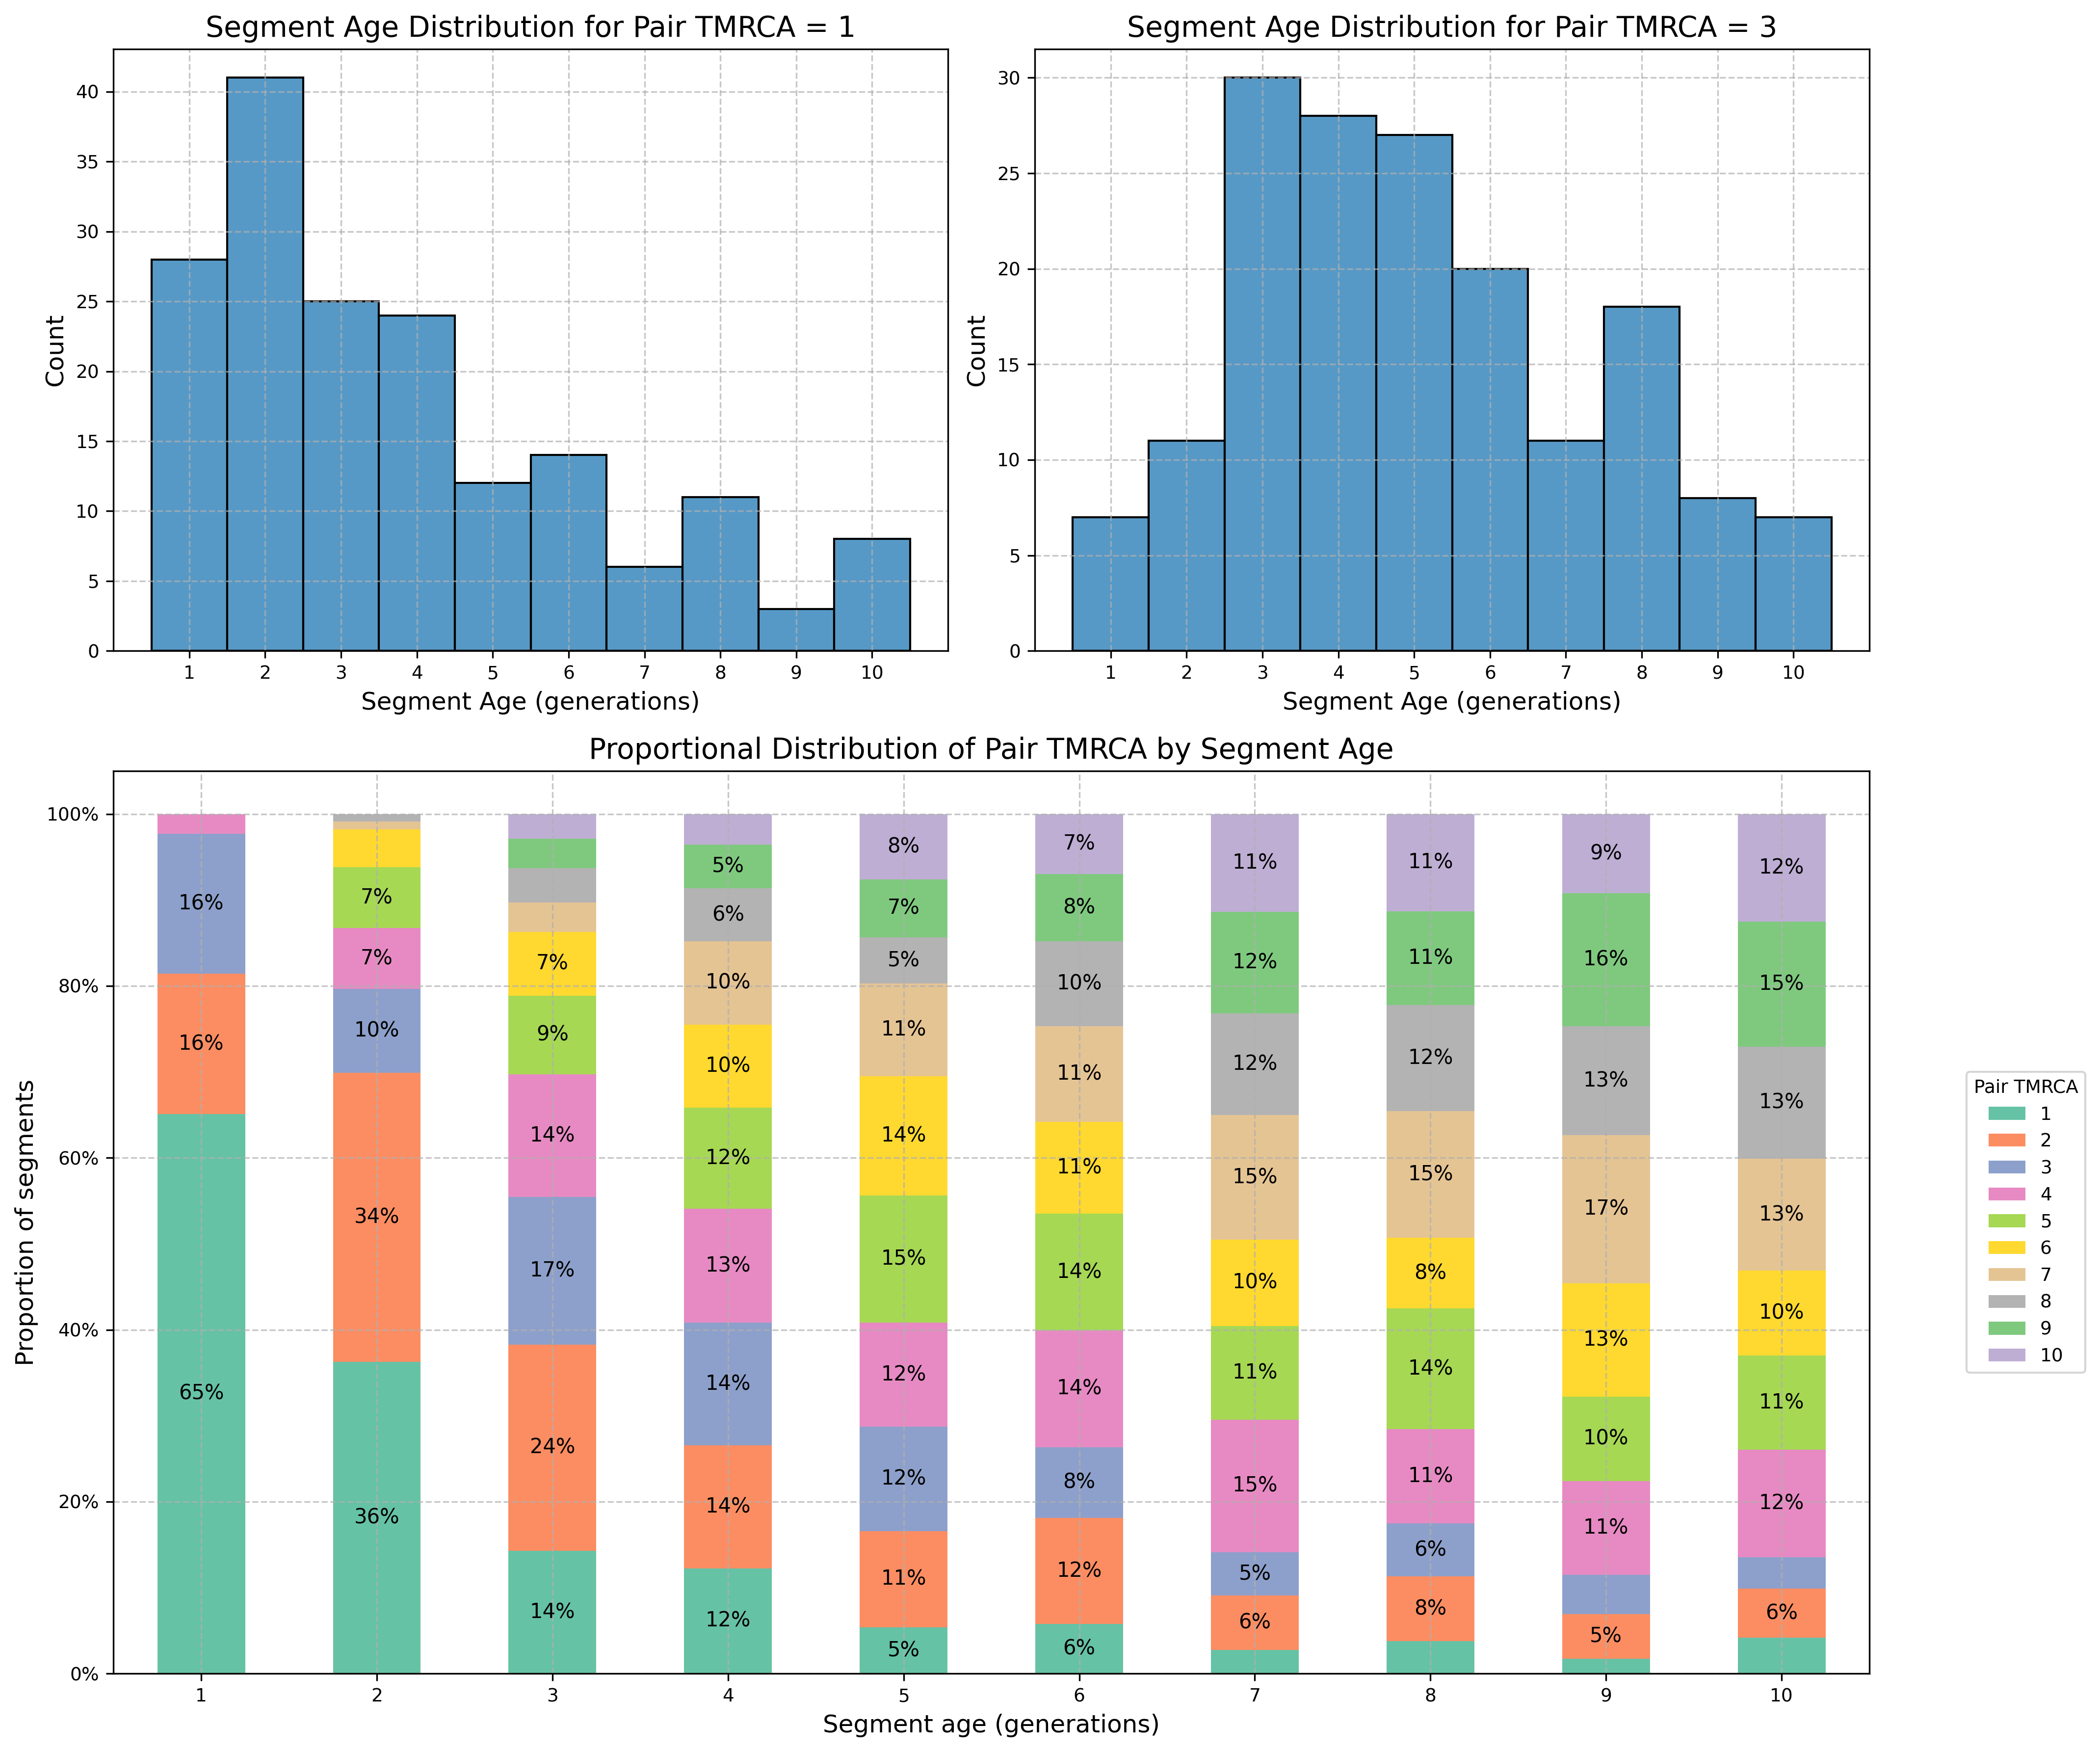

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def create_proportional_stacked_barplot(plot_df, ax=None):
    """
    Create a proportional stacked barplot showing the distribution of pair_tmrca values (1-10)
    for each segment age (1-10).
    
    Parameters:
    -----------
    plot_df : pandas.DataFrame
        DataFrame containing 'segment_age' and 'pair_tmrca' columns
    ax : matplotlib.axes.Axes, optional
        The axes to plot on. If None, a new figure and axes will be created.
        
    Returns:
    --------
    matplotlib.axes.Axes
        The axes object containing the stacked barplot
    """
    # Create a copy to avoid modifying the original
    df = plot_df.copy()
    
    # Ensure segment_age and pair_tmrca are numeric
    df['segment_age'] = pd.to_numeric(df['segment_age'], errors='coerce')
    df['pair_tmrca'] = pd.to_numeric(df['pair_tmrca'], errors='coerce')
    
    # Filter to include only segment ages 1-10
    df = df[df['segment_age'].between(1, 10)]
    
    # Filter to include only pair_tmrca 1-10
    df = df[df['pair_tmrca'].between(1, 10)]
    
    # Count occurrences for each combination of segment_age and pair_tmrca
    stacked_data = pd.crosstab(df['segment_age'], df['pair_tmrca'], normalize='index')
    
    # Ensure all segment_ages from 1-10 are included
    all_segment_ages = pd.Series(range(1, 11), name='segment_age')
    stacked_data = stacked_data.reindex(all_segment_ages)
    
    # Ensure all pair_tmrca values from 1-10 are included as columns
    all_pair_tmrca = list(range(1, 11))
    stacked_data = stacked_data.reindex(columns=all_pair_tmrca, fill_value=0)
    
    # Create figure and axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
    
    # Use a colorblind-friendly palette with 10 colors (for pair_tmrca 1-10)
    colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', 
              '#ffd92f', '#e5c494', '#b3b3b3', '#7fc97f', '#beaed4']
    
    stacked_data.plot(kind='bar', stacked=True, ax=ax, color=colors)
    
    # Customize the plot
    ax.set_xlabel('Segment age (generations)', fontsize=12)
    ax.set_ylabel('Proportion of segments', fontsize=12)
    # Place legend outside the plot on the right
    ax.legend(title='Pair TMRCA', loc='center left', bbox_to_anchor=(1.05, 0.5))
    
    # Format y-axis as percentage
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
    
    # Add percentage labels on bars for segments > 5%
    for c in ax.containers:
        # Only add labels to visible segments (value > 0.05)
        labels = [f'{v:.0%}' if v > 0.05 else '' for v in c.datavalues]
        ax.bar_label(c, labels=labels, label_type='center')
    
    # Set x-ticks to integer values 1-10
    ax.set_xticks(range(10))
    ax.set_xticklabels(range(1, 11), rotation=0)
    
    return ax

def create_three_panel_figure(plot_df):
    """
    Create a three-panel figure with:
    - Top row: Two histograms showing segment_age for pair_tmrca=1 and pair_tmrca=3
    - Bottom row: Proportional stacked barplot showing distribution of pair_tmrca values
    
    Parameters:
    -----------
    plot_df : pandas.DataFrame
        DataFrame containing 'segment_age' and 'pair_tmrca' columns
        
    Returns:
    --------
    matplotlib.figure.Figure
        The figure object containing the three panels
    """
    # Create a figure with a 2x2 grid, but the bottom panel will span both columns
    fig = plt.figure(figsize=(15, 12))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.5])
    
    # Top left panel: Histogram for pair_tmrca=1
    ax1 = fig.add_subplot(gs[0, 0])
    sns.histplot(
        data=plot_df[(plot_df.pair_tmrca==1) & (plot_df.segment_age<=10)], 
        x="segment_age", 
        ax=ax1,
        bins=range(1, 12),  # Bins from 1 to 11 to get integer x-values
        discrete=True
    )
    ax1.set_title('Segment Age Distribution for Pair TMRCA = 1', fontsize=14)
    ax1.set_xlabel('Segment Age (generations)', fontsize=12)
    ax1.set_ylabel('Count', fontsize=12)
    ax1.set_xticks(range(1, 11))
    
    # Top right panel: Histogram for pair_tmrca=3
    ax2 = fig.add_subplot(gs[0, 1])
    sns.histplot(
        data=plot_df[(plot_df.pair_tmrca==3) & (plot_df.segment_age<=10)], 
        x="segment_age", 
        ax=ax2,
        bins=range(1, 12),  # Bins from 1 to 11 to get integer x-values
        discrete=True
    )
    ax2.set_title('Segment Age Distribution for Pair TMRCA = 3', fontsize=14)
    ax2.set_xlabel('Segment Age (generations)', fontsize=12)
    ax2.set_ylabel('Count', fontsize=12)
    ax2.set_xticks(range(1, 11))
    
    # Bottom panel: Stacked barplot spanning both columns
    ax3 = fig.add_subplot(gs[1, :])
    create_proportional_stacked_barplot(plot_df, ax=ax3)
    ax3.set_title('Proportional Distribution of Pair TMRCA by Segment Age', fontsize=14)
    
    # Adjust layout
    plt.tight_layout()
    # Extra space for legend in the bottom panel
    plt.subplots_adjust(right=0.85)
    
    return fig

# Example usage:
fig = create_three_panel_figure(plot_df)
plt.savefig(f"{path}/pair_tmrca.png", dpi=500)
# plt.show()